In [1]:
import os
import pandas as pd
import json
import requests
import time
from tqdm.auto import tqdm
from google import genai
from dotenv import load_dotenv
import pickle
import random

load_dotenv()
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

# Initialize Google Gemini client
client = genai.Client(api_key=GOOGLE_API_KEY)


In [2]:
food_cat_df = pd.read_csv("food_cat_df.csv",index_col=0)
food_cat_df

,food_name,food_name_safe,main_category,secondary_category,third_category
0,nespresso,nespresso,BEVERAGES,Coffee and Tea,Coffee
1,oatmeal,oatmeal,GRAINS,Cooked Cereals,Oatmeal
2,milk,milk,MILK AND DAIRY,Milk,"Milk, whole"
3,eggplant,eggplant,VEGETABLES,"Vegetables, excluding potatoes",Other vegetables and combinations
4,lasagna,lasagna,MIXED DISHES,Mixed Dishes – Grain-based,"Pasta mixed dishes, excludes macaroni & cheese"
...,...,...,...,...,...
2658,asahi vegan beer,asahi_vegan_beer,ALCOHOLIC BEVERAGES,Alcoholic Beverages,Beer
2659,eye of round roast,eye_of_round_roast,PROTEIN FOODS,Meats,"Beef, excludes ground"
2660,whey hydrolysate isolate zero,whey_hydrolysate_isolate_zero,OTHER,Other,Protein and nutritional powders
2661,barukas,barukas,PROTEIN FOODS,Plant-based Protein Foods,Nuts and seeds


In [8]:
food_cat_df[(food_cat_df['main_category'] == 'PROTEIN FOODS') & (food_cat_df['secondary_category'] == 'Plant-based Protein Foods') & (food_cat_df['third_category'] == 'Nuts and seeds')]

,food_name,food_name_safe,main_category,secondary_category,third_category
8,peanut butter,peanut_butter,PROTEIN FOODS,Plant-based Protein Foods,Nuts and seeds
29,sunflower seed,sunflower_seed,PROTEIN FOODS,Plant-based Protein Foods,Nuts and seeds
33,pecan,pecan,PROTEIN FOODS,Plant-based Protein Foods,Nuts and seeds
34,chia seed,chia_seed,PROTEIN FOODS,Plant-based Protein Foods,Nuts and seeds
45,sesame seed,sesame_seed,PROTEIN FOODS,Plant-based Protein Foods,Nuts and seeds
53,macadamia,macadamia,PROTEIN FOODS,Plant-based Protein Foods,Nuts and seeds
107,walnut,walnut,PROTEIN FOODS,Plant-based Protein Foods,Nuts and seeds
118,almond,almond,PROTEIN FOODS,Plant-based Protein Foods,Nuts and seeds
124,pumpkin seed,pumpkin_seed,PROTEIN FOODS,Plant-based Protein Foods,Nuts and seeds
146,pistachio,pistachio,PROTEIN FOODS,Plant-based Protein Foods,Nuts and seeds


In [9]:
from pydantic import BaseModel, Field
from typing import List, Optional, Dict, Any
import os
import json
import time
import random
from tqdm.auto import tqdm

# Enhanced food models with USDA categories and micronutrients
class ServingSize(BaseModel):
    grams: float = Field(description="Serving size in grams")
    household: str = Field(description="Household measure (e.g., '1 cup')")

class Macronutrients(BaseModel):
    calories: float = Field(description="Energy in kcal")
    protein: float = Field(description="Protein content in grams")
    fat: float = Field(description="Fat content in grams")
    carbohydrates: float = Field(description="Carbohydrate content in grams")
    fiber: float = Field(description="Dietary fiber in grams")
    sugar: Optional[float] = Field(description="Sugar content in grams")
    saturated_fat: Optional[float] = Field(description="Saturated fat content in grams")
    cholesterol: Optional[float] = Field(description="Cholesterol content in milligrams")
    sodium: Optional[float] = Field(description="Sodium content in milligrams")

class Micronutrients(BaseModel):
    calcium: Optional[float] = Field(description="Calcium content in milligrams")
    iron: Optional[float] = Field(description="Iron content in milligrams")
    potassium: Optional[float] = Field(description="Potassium content in milligrams")
    vitamin_a: Optional[float] = Field(description="Vitamin A content in micrograms RAE")
    vitamin_c: Optional[float] = Field(description="Vitamin C content in milligrams")
    vitamin_d: Optional[float] = Field(description="Vitamin D content in micrograms")
    vitamin_e: Optional[float] = Field(description="Vitamin E content in milligrams")
    vitamin_k: Optional[float] = Field(description="Vitamin K content in micrograms")
    thiamin: Optional[float] = Field(description="Thiamin (B1) content in milligrams")
    riboflavin: Optional[float] = Field(description="Riboflavin (B2) content in milligrams")
    niacin: Optional[float] = Field(description="Niacin (B3) content in milligrams")
    vitamin_b6: Optional[float] = Field(description="Vitamin B6 content in milligrams")
    folate: Optional[float] = Field(description="Folate content in micrograms DFE")
    vitamin_b12: Optional[float] = Field(description="Vitamin B12 content in micrograms")
    phosphorus: Optional[float] = Field(description="Phosphorus content in milligrams")
    magnesium: Optional[float] = Field(description="Magnesium content in milligrams")
    zinc: Optional[float] = Field(description="Zinc content in milligrams")
    selenium: Optional[float] = Field(description="Selenium content in micrograms")

class USDACategory(BaseModel):
    main_category: str = Field(description="Main USDA food category")
    secondary_category: str = Field(description="Secondary USDA food category")
    third_category: str = Field(description="Third USDA food category")

# Enhanced food info model
class EnhancedFoodInfo(BaseModel):
    food_name: str = Field(description="Standardized name of the food item")
    description: str = Field(description="Brief description of what this food is")
    serving_size: ServingSize = Field(description="Standard serving size information")
    macronutrients_per_100g: Macronutrients = Field(description="Macronutrient content per 100g")
    micronutrients_per_100g: Micronutrients = Field(description="Micronutrient content per 100g")
    usda_category: USDACategory = Field(description="USDA food categorization")
    ingredients: List[str] = Field(description="Typical ingredients if it's a prepared food")
    variants: List[str] = Field(description="Common variants or alternative names")

def analyze_food_item(food_row, client, model, base_delay=1.0, max_retries=3):
    """
    Analyze a food item with USDA categories and save the result as a JSON file

    Args:
        food_row: Row from food_cat_df with food and category information
        client: Initialized Gemini client
        output_dir: Directory to save JSON results
        base_delay: Base delay between retries in seconds
        max_retries: Maximum number of retry attempts

    Returns:
        EnhancedFoodInfo object or None if analysis fails
    """
    output_dir = f"food_classification/{model}"
    # Extract food name and safe name
    food_name = food_row['food_name']
    food_name_safe = food_row['food_name_safe']

    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    # Use the safe filename
    json_path = os.path.join(output_dir, f"{food_name_safe}.json")

    # Check if we already have results for this food
    if os.path.exists(json_path):
        try:
            with open(json_path, 'r') as f:
                existing_data = json.load(f)
                print(f"Using existing data for '{food_name}'")
                # Convert the JSON back to an EnhancedFoodInfo object
                return EnhancedFoodInfo(**existing_data)
        except (json.JSONDecodeError, ValueError) as e:
            # If the file is corrupted or invalid, we'll re-analyze
            print(f"Found invalid cached data for '{food_name}', re-analyzing: {e}")

    # Create the prompt with USDA category information
    prompt = f"""
    Analyze this food item in detail: {food_name}

    USDA Category Information:
    - Main Category: {food_row['main_category']}
    - Secondary Category: {food_row['secondary_category']}
    - Third Category: {food_row['third_category']}

    Provide comprehensive nutritional information:
    1. Standardized name and detailed description
    2. Standard serving size (in grams and household measures)
    3. Complete macronutrients per 100g (calories, protein, fat, carbs, fiber, sugar, etc.)
    4. Micronutrients/vitamins per 100g (calcium, iron, vitamin A, C, D, etc.)
    5. Component ingredients (if it's a prepared food)
    6. Common variants or alternative names
    7. Preparation methods and health considerations

    For nutrient values, provide reasonable estimates based on nutrition databases. If precise data isn't available for micronutrients, provide plausible estimates based on similar foods.
    """

    # Try with exponential backoff
    for attempt in range(max_retries + 1):
        try:
            # Request analysis from Gemini with schema enforcement
            response = client.models.generate_content(
                model=model,
                contents=prompt,
                config={
                    'response_mime_type': 'application/json',
                    'response_schema': EnhancedFoodInfo,
                    'system_instruction': 'You are a nutrition database expert. Provide accurate, detailed food information including macronutrients, micronutrients, and USDA categorization.',
                    'temperature': 0.0
                }
            )

            # Get the parsed result
            result = response.parsed

            # Ensure the USDA category in the result matches our input
            result.usda_category.main_category = food_row['main_category']
            result.usda_category.secondary_category = food_row['secondary_category']
            result.usda_category.third_category = food_row['third_category']

            # Save the result to a JSON file
            with open(json_path, 'w') as f:
                json.dump(result.model_dump(), f, indent=2)

            print(f"Successfully analyzed and saved '{food_name}'")
            return result

        except Exception as e:
            if attempt < max_retries:
                # Calculate delay with exponential backoff and a bit of jitter
                delay = base_delay * (2 ** attempt) + random.uniform(0, 0.5)
                print(f"Error analyzing '{food_name}' (attempt {attempt+1}/{max_retries+1}): {e}")
                print(f"Retrying in {delay:.1f} seconds...")
                time.sleep(delay)
            else:
                print(f"Failed to analyze '{food_name}' after {max_retries+1} attempts: {e}")
                return None

def process_foods_batch(food_cat_df, client, start_idx=0, end_idx=None, model="gemini-2.0-flash"):
    """
    Process a batch of foods from the dataframe

    Args:
        food_cat_df: DataFrame with foods and their USDA categories
        client: Initialized Gemini client
        start_idx: Starting index in the dataframe
        end_idx: Ending index in the dataframe (None for end of dataframe)
        output_dir: Directory to save JSON results

    Returns:
        Number of successfully processed foods
    """
    if end_idx is None:
        end_idx = len(food_cat_df)

    print(f"Processing foods from index {start_idx} to {end_idx-1}")

    # Process foods in the specified range
    successful = 0
    for idx in tqdm(range(start_idx, end_idx), desc="Processing foods"):
        if idx >= len(food_cat_df):
            break

        row = food_cat_df.iloc[idx]

        # Analyze and save each food
        result = analyze_food_item(row, client, model)

        if result:
            successful += 1

    print(f"Completed processing batch: {successful}/{end_idx-start_idx} foods processed successfully")
    return successful

# Example usage:
# To process the first 10 foods:
process_foods_batch(food_cat_df, client, 0, 10)
#
# To process the next 10 foods:
# process_foods_batch(food_cat_df, client, 10, 20)
#
# To process all remaining foods:
# process_foods_batch(food_cat_df, client, 10)

Processing foods from index 0 to 9


Processing foods:   0%|          | 0/10 [00:00<?, ?it/s]

Successfully analyzed and saved 'nespresso'
Successfully analyzed and saved 'oatmeal'
Successfully analyzed and saved 'milk'
Successfully analyzed and saved 'eggplant'
Successfully analyzed and saved 'lasagna'
Successfully analyzed and saved 'spinach'
Successfully analyzed and saved 'pita bread'
Successfully analyzed and saved 'egg'
Successfully analyzed and saved 'peanut butter'
Successfully analyzed and saved 'oat milk'
Completed processing batch: 10/10 foods processed successfully


10

In [6]:
process_foods_batch(food_cat_df, client, 10)

Processing foods from index 10 to 2662


Processing foods:   0%|          | 0/2653 [00:00<?, ?it/s]

Successfully analyzed and saved 'lungo'
Successfully analyzed and saved 'brownie'
Successfully analyzed and saved 'zucchini'
Successfully analyzed and saved 'pancake'
Successfully analyzed and saved 'lettuce'
Successfully analyzed and saved 'hummus'
Successfully analyzed and saved 'banana'
Successfully analyzed and saved 'corn'
Successfully analyzed and saved 'chicken'
Successfully analyzed and saved 'broccoli'
Successfully analyzed and saved 'risotto'
Successfully analyzed and saved 'cocoa'
Successfully analyzed and saved 'chamomile tea'
Successfully analyzed and saved 'avocado'
Successfully analyzed and saved 'pretzel'
Successfully analyzed and saved 'blueberry'
Successfully analyzed and saved 'apple'
Successfully analyzed and saved 'muffin'
Successfully analyzed and saved 'brussels sprout'
Successfully analyzed and saved 'sunflower seed'
Successfully analyzed and saved 'sausage'
Successfully analyzed and saved 'rice'
Successfully analyzed and saved 'ice cream'
Successfully analyzed 

2651

In [3]:
import json
import os

def load_json_files_to_dict(directory_path):
    """
    Loads all JSON files from a directory and stores them in a dictionary of dictionaries.

    Args:
        directory_path: The path to the directory containing the JSON files.

    Returns:
        A dictionary where the keys are the filenames (without extension) and the values
        are the dictionaries loaded from the JSON files.  Returns an empty dictionary
        if the directory doesn't exist or is empty, or if no JSON files are found.
    """

    data = {}
    try:
        # Check if the directory exists
        if not os.path.exists(directory_path):
            print(f"Error: Directory '{directory_path}' does not exist.")
            return {}

        # Iterate through files in the directory
        for filename in os.listdir(directory_path):
            if filename.endswith(".json"):
                filepath = os.path.join(directory_path, filename)

                try:
                    with open(filepath, 'r', encoding='utf-8') as f:  # Explicit encoding for broader compatibility
                        # Try to load the JSON data
                        try:
                            json_data = json.load(f)
                            # Use filename without extension as the key
                            key = os.path.splitext(filename)[0]  # Remove .json extension
                            data[key] = json_data
                        except json.JSONDecodeError as e:
                            print(f"Error decoding JSON in file '{filename}': {e}")

                except FileNotFoundError:  # Should theoretically not occur, but just in case.
                    print(f"Error: File '{filename}' not found (even though it was listed).")
                except IOError as e:  # catch other file related errors
                    print(f"Error: Could not open or read file '{filename}': {e}")

    except OSError as e:
        print(f"Error accessing directory '{directory_path}': {e}")

    return data


# Example usage:
directory = "enhanced_food_info" # Replace with the correct directory name

food_data = load_json_files_to_dict(directory)

In [4]:
food_data

{'chocolate_cookie': {'food_name': 'Chocolate Cookie',
  'description': 'A sweet baked treat, typically made with flour, sugar, butter, eggs, and chocolate or chocolate flavoring. Variations include different types of chocolate, nuts, and fillings.',
  'serving_size': {'grams': 30.0, 'household': '1 medium cookie'},
  'macronutrients_per_100g': {'calories': 480.0,
   'protein': 5.0,
   'fat': 25.0,
   'carbohydrates': 60.0,
   'fiber': 2.0,
   'sugar': 30.0,
   'saturated_fat': 15.0,
   'cholesterol': 50.0,
   'sodium': 250.0},
  'micronutrients_per_100g': {'calcium': 30.0,
   'iron': 2.0,
   'potassium': 150.0,
   'vitamin_a': 50.0,
   'vitamin_c': 0.0,
   'vitamin_d': 0.0,
   'vitamin_e': 0.5,
   'vitamin_k': 2.0,
   'thiamin': 0.1,
   'riboflavin': 0.1,
   'niacin': 0.5,
   'vitamin_b6': 0.05,
   'folate': 15.0,
   'vitamin_b12': 0.0,
   'phosphorus': 80.0,
   'magnesium': 20.0,
   'zinc': 0.5,
   'selenium': 5.0},
  'usda_category': {'main_category': 'SNACKS AND SWEETS',
   'second

In [5]:
import pandas as pd

def convert_dict_to_dataframe(data_dict):
    """
    Converts a dictionary of dictionaries to a Pandas DataFrame, using the keys of the
    outer dictionary as the index of the DataFrame.

    Args:
        data_dict: A dictionary where the keys represent the index of the DataFrame, and
              the values are dictionaries representing the rows.

    Returns:
        A Pandas DataFrame created from the input dictionary.
        Returns an empty DataFrame if the input dictionary is empty or if there is an error during conversion.
    """
    try:
        if not data_dict:  # Check if the dictionary is empty
            print("Warning: Input dictionary is empty. Returning an empty DataFrame.")
            return pd.DataFrame()

        df = pd.DataFrame.from_dict(data_dict, orient='index')
        return df
    except Exception as e:
        print(f"Error converting dictionary to DataFrame: {e}")
        return pd.DataFrame()  # Return empty DataFrame on conversion error


# Example Usage (assuming you already have 'food_data' from the previous code):
# food_data = load_json_files_to_dict(directory)  # Assuming you already have this from before

food_dataframe_result = convert_dict_to_dataframe(food_data)


In [6]:
food_dataframe_result.columns

Index(['food_name', 'description', 'serving_size', 'macronutrients_per_100g',
       'micronutrients_per_100g', 'usda_category', 'ingredients', 'variants'],
      dtype='object')

In [7]:
import pandas as pd
import json
import time
import numpy as np
import os
from tqdm import tqdm  # Make sure to install tqdm: pip install tqdm

# Assuming you have the 'anthropic' client initialized as 'client'

def transform_row_to_text(row, columns):
    """
    Transforms a row of a DataFrame into a single text string by concatenating
    the values from the specified columns.

    Args:
        row (pd.Series): A row from a DataFrame.
        columns (list of str): The names of the columns to include in the text.

    Returns:
        str: A single string containing the concatenated values from the selected columns.
    """
    text_parts = []
    for col in columns:
        # Handle missing values gracefully (replace with an empty string)
        value = str(row[col]) if pd.notna(row[col]) else ""
        text_parts.append(value)

    return " ".join(text_parts)


def batch_get_embeddings_from_dataframe(df, columns, embeddings_outdir=None, batch_size=100):
    """
    Get embeddings for a DataFrame, transforming rows into text before embedding.
    Creates embedding column name based on concatenated column names.

    Args:
        df (pd.DataFrame): The DataFrame to embed.
        columns (list of str): The names of the columns to use for text transformation.
        embeddings_outdir (str): Directory to save embeddings to. If None, embeddings are not saved.
        batch_size (int): The batch size for the embedding API.

    Returns:
        dict: A dictionary where keys are the DataFrame index and values are dictionaries
              containing 'item_text' (the generated text) and 'embedding' (the numpy array embedding).
        str: The name of the embedding column created (for use when joining back to the original DataFrame).
    """
    all_embeddings = {}

    # Create embedding column name from concatenated column names
    embedding_col_name = f"embedding_{'-'.join(columns)}"

    # Create embeddings directory if it doesn't exist
    if embeddings_outdir and not os.path.exists(embeddings_outdir):
        os.makedirs(embeddings_outdir)

    for i in tqdm(range(0, len(df), batch_size), desc="Processing embedding batches"):
        batch_df = df.iloc[i:i+batch_size]  # Get a DataFrame slice (batch)

        batch_texts = [transform_row_to_text(row, columns) for index, row in batch_df.iterrows()]
        batch_contents = batch_texts  # Directly using the transformed texts

        try:
            # Use the batch embedding endpoint
            response = client.models.embed_content(
                model="text-embedding-004",
                contents=list(batch_contents)
            )

            # Extract embeddings
            for idx, embedding_result in enumerate(response.embeddings):
                index = batch_df.index[idx]  # Get the original index
                item_text = batch_texts[idx]
                all_embeddings[index] = {}
                all_embeddings[index]['item_text'] = item_text
                all_embeddings[index]['embedding'] = np.array(embedding_result.values)

            # Small delay between batch requests if needed
            if i + batch_size < len(df):
                time.sleep(0.5)

        except Exception as e:
            print(f"Error in batch {i//batch_size + 1}: {e}")
            # Fall back to individual requests for this batch
            for idx, item_text in enumerate(batch_texts):
                index = batch_df.index[idx]  # Get the original index
                try:
                    response = client.models.embed_content(
                        model="text-embedding-004",
                        contents=item_text
                    )
                    all_embeddings[index] = {}
                    all_embeddings[index]['item_text'] = item_text
                    all_embeddings[index]['embedding'] = np.array(response.embedding.values)
                except Exception as inner_e:
                    print(f"Failed to get embedding for index '{index}': {inner_e}")

    # Save embeddings to file if output directory is provided
    if embeddings_outdir:
        # Convert numpy arrays to lists for JSON serialization
        serializable_embeddings = {}
        for idx, data in all_embeddings.items():
            serializable_embeddings[str(idx)] = {
                'item_text': data['item_text'],
                'embedding': data['embedding'].tolist()
            }

        # Save to JSON file with name based on the columns used
        embedding_filename = f"{'-'.join(columns)}_embeddings.json"
        with open(os.path.join(embeddings_outdir, embedding_filename), 'w') as f:
            json.dump(serializable_embeddings, f)

        print(f"Embeddings saved to {os.path.join(embeddings_outdir, embedding_filename)}")

    return all_embeddings, embedding_col_name


def join_embeddings_to_dataframe(df, embeddings_dict, embedding_col_name):
    """
    Joins the embeddings back to the original DataFrame with a dynamically named column.

    Args:
        df (pd.DataFrame): The original DataFrame.
        embeddings_dict (dict): Dictionary with embeddings as returned by batch_get_embeddings_from_dataframe.
        embedding_col_name (str): Name to use for the embedding column.

    Returns:
        pd.DataFrame: Original DataFrame with embeddings added.
    """
    # Create a new DataFrame from the embeddings dictionary
    embeddings_df = pd.DataFrame.from_dict(embeddings_dict, orient='index')

    # Rename the 'embedding' column to the dynamic embedding column name
    if 'embedding' in embeddings_df.columns:
        embeddings_df.rename(columns={'embedding': embedding_col_name}, inplace=True)

    # Join with the original DataFrame
    return df.join(embeddings_df)


# Example usage:
selected_columns = ['food_name', 'description', 'usda_category']
embeddings_outdir = 'embeddings_output'  # Replace with your desired output directory

# Get embeddings and the generated column name
embeddings_dict, embedding_col_name = batch_get_embeddings_from_dataframe(
    food_dataframe_result,
    selected_columns,
    embeddings_outdir=embeddings_outdir
)

# Join embeddings back to the original DataFrame with the dynamic column name
final_df = join_embeddings_to_dataframe(food_dataframe_result, embeddings_dict, embedding_col_name)

# Display the results
print(f"Created embedding column: {embedding_col_name}")
display(final_df.head())

Processing embedding batches: 100%|██████████| 27/27 [00:37<00:00,  1.37s/it]


Embeddings saved to embeddings_output/food_name-description-usda_category_embeddings.json
Created embedding column: embedding_food_name-description-usda_category


,food_name,description,serving_size,macronutrients_per_100g,micronutrients_per_100g,usda_category,ingredients,variants,item_text,embedding_food_name-description-usda_category
chocolate_cookie,Chocolate Cookie,"A sweet baked treat, typically made with flour...","{'grams': 30.0, 'household': '1 medium cookie'}","{'calories': 480.0, 'protein': 5.0, 'fat': 25....","{'calcium': 30.0, 'iron': 2.0, 'potassium': 15...","{'main_category': 'SNACKS AND SWEETS', 'second...","[Flour, Sugar, Butter, Eggs, Chocolate chips o...","[Chocolate chip cookie, Double chocolate cooki...","Chocolate Cookie A sweet baked treat, typicall...","[-0.0016493461, -0.0022579378, 0.014673492, -0..."
green_apple_amino_energy,Amino Energy Green Apple,"A green apple flavored, lightly carbonated bev...","{'grams': 9.0, 'household': '1 scoop (approxim...","{'calories': 0.0, 'protein': 0.0, 'fat': 0.0, ...","{'calcium': None, 'iron': None, 'potassium': N...","{'main_category': 'BEVERAGES', 'secondary_cate...","[Amino Blend (L-Glutamine, L-Leucine, L-Argini...","[Various flavors (e.g., Fruit Fusion, Watermel...",Amino Energy Green Apple A green apple flavore...,"[0.008850878, 0.029284129, -0.022166818, -0.05..."
bud_light_beer,Bud Light Beer,A light-bodied American lager known for its cr...,"{'grams': 355.0, 'household': '1 can (12 fl oz)'}","{'calories': 28.0, 'protein': 0.2, 'fat': 0.0,...","{'calcium': 2.0, 'iron': 0.01, 'potassium': 5....","{'main_category': 'ALCOHOLIC BEVERAGES', 'seco...","[Water, Barley Malt, Rice, Hops, Yeast]","[Bud Light Lime, Bud Light Platinum, Bud Light...",Bud Light Beer A light-bodied American lager k...,"[0.015487557, -0.029944913, -0.007987696, -0.0..."
banana_chip,Banana Chips,"Dried or dehydrated slices of bananas, often f...","{'grams': 28.0, 'household': '1/4 cup'}","{'calories': 519.0, 'protein': 2.3, 'fat': 33....","{'calcium': 17.0, 'iron': 0.7, 'potassium': 35...","{'main_category': 'FRUIT', 'secondary_category...","[Bananas, Coconut Oil, Sugar, Flavor]","[Dehydrated Banana Slices, Fried Banana Chips,...",Banana Chips Dried or dehydrated slices of ban...,"[-0.041218117, -0.020939495, -0.00084499986, -..."
oyster,"Oysters, raw",Raw oysters are a type of shellfish known for ...,"{'grams': 85.0, 'household': '6 medium oysters'}","{'calories': 81.0, 'protein': 9.4, 'fat': 2.3,...","{'calcium': 80.0, 'iron': 5.0, 'potassium': 17...","{'main_category': 'PROTEIN FOODS', 'secondary_...","[Raw oyster meat, Oyster liquor (natural juices)]","[Pacific Oyster, Eastern Oyster, Olympia Oyste...","Oysters, raw Raw oysters are a type of shellfi...","[0.040493697, 0.024074009, -0.034531366, -0.03..."


In [13]:
final_df.iloc[0]['usda_category']

{'main_category': 'SNACKS AND SWEETS',
 'secondary_category': 'Sweet Bakery Products',
 'third_category': 'Cookies and brownies'}

In [14]:
final_df

,food_name,description,serving_size,macronutrients_per_100g,micronutrients_per_100g,usda_category,ingredients,variants,item_text,embedding_food_name-description-usda_category
chocolate_cookie,Chocolate Cookie,"A sweet baked treat, typically made with flour...","{'grams': 30.0, 'household': '1 medium cookie'}","{'calories': 480.0, 'protein': 5.0, 'fat': 25....","{'calcium': 30.0, 'iron': 2.0, 'potassium': 15...","{'main_category': 'SNACKS AND SWEETS', 'second...","[Flour, Sugar, Butter, Eggs, Chocolate chips o...","[Chocolate chip cookie, Double chocolate cooki...","Chocolate Cookie A sweet baked treat, typicall...","[-0.0016493461, -0.0022579378, 0.014673492, -0..."
green_apple_amino_energy,Amino Energy Green Apple,"A green apple flavored, lightly carbonated bev...","{'grams': 9.0, 'household': '1 scoop (approxim...","{'calories': 0.0, 'protein': 0.0, 'fat': 0.0, ...","{'calcium': None, 'iron': None, 'potassium': N...","{'main_category': 'BEVERAGES', 'secondary_cate...","[Amino Blend (L-Glutamine, L-Leucine, L-Argini...","[Various flavors (e.g., Fruit Fusion, Watermel...",Amino Energy Green Apple A green apple flavore...,"[0.008850878, 0.029284129, -0.022166818, -0.05..."
bud_light_beer,Bud Light Beer,A light-bodied American lager known for its cr...,"{'grams': 355.0, 'household': '1 can (12 fl oz)'}","{'calories': 28.0, 'protein': 0.2, 'fat': 0.0,...","{'calcium': 2.0, 'iron': 0.01, 'potassium': 5....","{'main_category': 'ALCOHOLIC BEVERAGES', 'seco...","[Water, Barley Malt, Rice, Hops, Yeast]","[Bud Light Lime, Bud Light Platinum, Bud Light...",Bud Light Beer A light-bodied American lager k...,"[0.015487557, -0.029944913, -0.007987696, -0.0..."
banana_chip,Banana Chips,"Dried or dehydrated slices of bananas, often f...","{'grams': 28.0, 'household': '1/4 cup'}","{'calories': 519.0, 'protein': 2.3, 'fat': 33....","{'calcium': 17.0, 'iron': 0.7, 'potassium': 35...","{'main_category': 'FRUIT', 'secondary_category...","[Bananas, Coconut Oil, Sugar, Flavor]","[Dehydrated Banana Slices, Fried Banana Chips,...",Banana Chips Dried or dehydrated slices of ban...,"[-0.041218117, -0.020939495, -0.00084499986, -..."
oyster,"Oysters, raw",Raw oysters are a type of shellfish known for ...,"{'grams': 85.0, 'household': '6 medium oysters'}","{'calories': 81.0, 'protein': 9.4, 'fat': 2.3,...","{'calcium': 80.0, 'iron': 5.0, 'potassium': 17...","{'main_category': 'PROTEIN FOODS', 'secondary_...","[Raw oyster meat, Oyster liquor (natural juices)]","[Pacific Oyster, Eastern Oyster, Olympia Oyste...","Oysters, raw Raw oysters are a type of shellfi...","[0.040493697, 0.024074009, -0.034531366, -0.03..."
...,...,...,...,...,...,...,...,...,...,...
avocado_oil,Avocado Oil,Edible oil extracted from the pulp of the avoc...,"{'grams': 14.0, 'household': '1 tablespoon'}","{'calories': 884.0, 'protein': 0.0, 'fat': 100...","{'calcium': 0.0, 'iron': 0.0, 'potassium': 0.0...","{'main_category': 'FATS AND OILS', 'secondary_...",[Avocado pulp],"[Refined avocado oil, Unrefined avocado oil, E...",Avocado Oil Edible oil extracted from the pulp...,"[0.014977352, -0.022873813, -0.03385646, -0.01..."
breakfast_bar,Breakfast Bar,"A processed food product, typically individual...","{'grams': 45.0, 'household': '1 bar'}","{'calories': 400.0, 'protein': 7.0, 'fat': 15....","{'calcium': 50.0, 'iron': 3.0, 'potassium': 15...","{'main_category': 'SNACKS AND SWEETS', 'second...","[Oats, Corn Syrup, Sugar, Vegetable Oil (Palm ...","[Granola Bar, Energy Bar, Protein Bar, Fruit a...","Breakfast Bar A processed food product, typica...","[-7.696682e-05, -0.04545606, -0.036479946, -0...."
fritos,Fritos Original Corn Chips,Fritos Original Corn Chips are a popular brand...,"{'grams': 28.0, 'household': 'About 1 ounce (a...","{'calories': 536.0, 'protein': 6.9, 'fat': 32....","{'calcium': 0.0, 'iron': 1.29, 'potassium': 10...","{'main_category': 'SNACKS AND SWEETS', 'second...","[Corn, Corn Oil, Salt]","[Fritos Scoops!, Fritos Chili Cheese Flavored ...",Fritos Original Corn Chips

In [15]:
import pandas as pd
import ast
import json

def extract_dict_columns(df, column_specs):
    """
    General function to extract values from dictionary columns and create new columns.

    Args:
        df (pd.DataFrame): DataFrame containing dictionary columns
        column_specs (list): List of dictionaries specifying extraction details:
            {
                'source_column': str,           # Name of the column containing dictionaries
                'extract_type': str,            # Type of extraction ('nutrition', 'serving', 'category', etc.)
                'prefix': str,                  # Prefix for new column names (optional)
                'default_type': type,           # Default type for values (float, str, etc.)
                'keys': list or None,           # Specific keys to extract (None for all keys)
                'default_value': any            # Default value for missing data
            }

    Returns:
        pd.DataFrame: DataFrame with extracted columns
    """
    df_result = df.copy()

    for spec in column_specs:
        source_column = spec['source_column']
        extract_type = spec['extract_type']
        prefix = spec.get('prefix', source_column + '_')
        default_type = spec.get('default_type', str)
        keys = spec.get('keys', None)
        default_value = spec.get('default_value', None)

        if extract_type == 'nutrition':
            df_result = extract_nutrition_data(df_result, source_column, prefix, default_value)
        elif extract_type == 'serving':
            df_result = extract_serving_size(df_result, source_column)
        elif extract_type == 'category':
            df_result = extract_usda_categories(df_result, source_column)
        elif extract_type == 'generic':
            df_result = extract_generic_dict(df_result, source_column, prefix, keys, default_type, default_value)

    return df_result

def parse_dict_string(dict_str):
    """
    Safely parse a string representation of a dictionary.
    Handles various formats and potential errors.

    Args:
        dict_str: String representation of a dictionary

    Returns:
        dict: Parsed dictionary or empty dict if parsing fails
    """
    if pd.isna(dict_str):
        return {}

    # Clean the string
    cleaned_str = str(dict_str).strip()
    cleaned_str = cleaned_str.replace('\\', '')
    cleaned_str = ''.join(c for c in cleaned_str if c.isprintable())

    # Try multiple parsing methods
    try:
        # Try ast.literal_eval first (safest)
        return ast.literal_eval(cleaned_str)
    except (ValueError, SyntaxError, TypeError):
        try:
            # Try json.loads as fallback
            return json.loads(cleaned_str)
        except json.JSONDecodeError:
            try:
                # Last resort: try eval with modified string (use with caution)
                cleaned_str = cleaned_str.replace("'", '"')
                return json.loads(cleaned_str)
            except:
                print(f"Error parsing dictionary string: {cleaned_str[:100]}...")
                return {}

def extract_nutrition_data(df, nutrition_col, prefix, default_value=0.0):
    """
    Extracts nutrition data from a column containing dictionary strings.
    Converts all values to float and handles missing values.

    Args:
        df (pd.DataFrame): DataFrame with nutrition data
        nutrition_col (str): Column name containing nutrition dictionaries
        prefix (str): Prefix for new column names
        default_value (float): Default value for missing nutrients (default: 0.0)

    Returns:
        pd.DataFrame: DataFrame with extracted nutrition columns
    """
    df_copy = df.copy()

    # Function to extract nutrients
    def extract_nutrient(row, nutrient):
        try:
            nutrient_dict = parse_dict_string(row)
            return float(nutrient_dict.get(nutrient, default_value))
        except (ValueError, TypeError):
            return default_value

    # Get all possible nutrients from the first few non-null rows
    all_nutrients = set()
    for _, row in df_copy.dropna(subset=[nutrition_col]).head(100).iterrows():
        nutrients = parse_dict_string(row[nutrition_col])
        all_nutrients.update(nutrients.keys())

    # Create columns for each nutrient
    for nutrient in all_nutrients:
        col_name = f"{prefix}{nutrient}"
        df_copy[col_name] = df_copy[nutrition_col].apply(
            lambda x: extract_nutrient(x, nutrient)
        )

    return df_copy

def extract_serving_size(df, serving_col):
    """
    Extracts serving size data from a column containing dictionary strings.
    Creates 'serving_grams' (float) and 'serving_household' (str) columns.

    Args:
        df (pd.DataFrame): DataFrame with serving size data
        serving_col (str): Column name containing serving size dictionaries

    Returns:
        pd.DataFrame: DataFrame with extracted serving size columns
    """
    df_copy = df.copy()

    # Extract grams (as float)
    df_copy['serving_grams'] = df_copy[serving_col].apply(
        lambda x: float(parse_dict_string(x).get('grams', 0.0))
        if not pd.isna(x) else 0.0
    )

    # Extract household description (as string)
    df_copy['serving_household'] = df_copy[serving_col].apply(
        lambda x: str(parse_dict_string(x).get('household', ''))
        if not pd.isna(x) else ''
    )

    return df_copy

def extract_usda_categories(df, usda_category_col):
    """
    Extracts USDA category data from a column containing dictionary strings.
    Creates columns for main, secondary, and third categories.

    Args:
        df (pd.DataFrame): DataFrame with USDA category data
        usda_category_col (str): Column name containing USDA category dictionaries

    Returns:
        pd.DataFrame: DataFrame with extracted USDA category columns
    """
    df_copy = df.copy()

    # Function to extract a category safely
    def get_category(row, key):
        category_dict = parse_dict_string(row)
        return str(category_dict.get(key, 'Missing'))

    # Extract categories
    df_copy['main_usda_category'] = df_copy[usda_category_col].apply(
        lambda x: get_category(x, 'main_category')
    )
    df_copy['secondary_usda_category'] = df_copy[usda_category_col].apply(
        lambda x: get_category(x, 'secondary_category')
    )
    df_copy['third_usda_category'] = df_copy[usda_category_col].apply(
        lambda x: get_category(x, 'third_category')
    )

    return df_copy

def extract_generic_dict(df, dict_col, prefix, keys=None, default_type=str, default_value=None):
    """
    Extracts values from any dictionary column based on specified keys.
    Allows control over data types and default values.

    Args:
        df (pd.DataFrame): DataFrame with dictionary data
        dict_col (str): Column name containing dictionaries
        prefix (str): Prefix for new column names
        keys (list): List of keys to extract (None for all keys)
        default_type (type): Type to convert values to
        default_value: Default value for missing data

    Returns:
        pd.DataFrame: DataFrame with extracted columns
    """
    df_copy = df.copy()

    # If keys not specified, infer from data
    if keys is None:
        keys = set()
        for _, row in df_copy.dropna(subset=[dict_col]).head(100).iterrows():
            dict_data = parse_dict_string(row[dict_col])
            keys.update(dict_data.keys())

    # Function to extract and convert values
    def extract_value(row, key):
        dict_data = parse_dict_string(row)
        value = dict_data.get(key, default_value)
        try:
            return default_type(value) if value is not None else default_value
        except (ValueError, TypeError):
            return default_value

    # Extract values for each key
    for key in keys:
        col_name = f"{prefix}{key}"
        df_copy[col_name] = df_copy[dict_col].apply(
            lambda x: extract_value(x, key)
        )

    return df_copy

# Example usage
def process_food_data(df):
    """
    Process a food dataframe by extracting all relevant dictionary columns
    """
    column_specs = [
        {
            'source_column': 'serving_size',
            'extract_type': 'serving',
        },
        {
            'source_column': 'macronutrients_per_100g',
            'extract_type': 'nutrition',
            'prefix': 'macro_',
            'default_type': float,
            'default_value': 0.0
        },
        {
            'source_column': 'micronutrients_per_100g',
            'extract_type': 'nutrition',
            'prefix': 'micro_',
            'default_type': float,
            'default_value': 0.0
        },
        {
            'source_column': 'usda_category',
            'extract_type': 'category',
        }
    ]

    return extract_dict_columns(df, column_specs)

# Example execution
# Assuming food_dataframe has the required columns
processed_df = process_food_data(final_df)
display(processed_df.head())

,food_name,description,serving_size,macronutrients_per_100g,micronutrients_per_100g,usda_category,ingredients,variants,item_text,embedding_food_name-description-usda_category,...,micro_magnesium,micro_vitamin_c,micro_phosphorus,micro_zinc,micro_riboflavin,micro_niacin,micro_potassium,main_usda_category,secondary_usda_category,third_usda_category
chocolate_cookie,Chocolate Cookie,"A sweet baked treat, typically made with flour...","{'grams': 30.0, 'household': '1 medium cookie'}","{'calories': 480.0, 'protein': 5.0, 'fat': 25....","{'calcium': 30.0, 'iron': 2.0, 'potassium': 15...","{'main_category': 'SNACKS AND SWEETS', 'second...","[Flour, Sugar, Butter, Eggs, Chocolate chips o...","[Chocolate chip cookie, Double chocolate cooki...","Chocolate Cookie A sweet baked treat, typicall...","[-0.0016493461, -0.0022579378, 0.014673492, -0...",...,20.0,0.0,80.0,0.50,0.100,0.5,150.0,SNACKS AND SWEETS,Sweet Bakery Products,Cookies and brownies
green_apple_amino_energy,Amino Energy Green Apple,"A green apple flavored, lightly carbonated bev...","{'grams': 9.0, 'household': '1 scoop (approxim...","{'calories': 0.0, 'protein': 0.0, 'fat': 0.0, ...","{'calcium': None, 'iron': None, 'potassium': N...","{'main_category': 'BEVERAGES', 'secondary_cate...","[Amino Blend (L-Glutamine, L-Leucine, L-Argini...","[Various flavors (e.g., Fruit Fusion, Watermel...",Amino Energy Green Apple A green apple flavore...,"[0.008850878, 0.029284129, -0.022166818, -0.05...",...,0.0,0.0,0.0,0.00,0.000,0.0,0.0,BEVERAGES,Sweetened Beverages,Sport and energy drinks
bud_light_beer,Bud Light Beer,A light-bodied American lager known for its cr...,"{'grams': 355.0, 'household': '1 can (12 fl oz)'}","{'calories': 28.0, 'protein': 0.2, 'fat': 0.0,...","{'calcium': 2.0, 'iron': 0.01, 'potassium': 5....","{'main_category': 'ALCOHOLIC BEVERAGES', 'seco...","[Water, Barley Malt, Rice, Hops, Yeast]","[Bud Light Lime, Bud Light Platinum, Bud Light...",Bud Light Beer A light-bodied American lager k...,"[0.015487557, -0.029944913, -0.007987696, -0.0...",...,2.0,0.0,6.0,0.01,0.008,0.1,5.0,ALCOHOLIC BEVERAGES,Alcoholic Beverages,Beer
banana_chip,Banana Chips,"Dried or dehydrated slices of bananas, often f...","{'grams': 28.0, 'household': '1/4 cup'}","{'calories': 519.0, 'protein': 2.3, 'fat': 33....","{'calcium': 17.0, 'iron': 0.7, 'potassium': 35...","{'main_category': 'FRUIT', 'secondary_category...","[Bananas, Coconut Oil, Sugar, Flavor]","[Dehydrated Banana Slices, Fried Banana Chips,...",Banana Chips Dried or dehydrated slices of ban...,"[-0.041218117, -0.020939495, -0.00084499986, -...",...,33.0,2.4,71.0,0.20,0.060,0.7,354.0,FRUIT,Fruits,Dried fruits
oyster,"Oysters, raw",Raw oysters are a type of shellfish known for ...,"{'grams': 85.0, 'household': '6 medium oysters'}","{'calories': 81.0, 'protein': 9.4, 'fat': 2.3,...","{'calcium': 80.0, 'iron': 5.0, 'potassium': 17...","{'main_category': 'PROTEIN FOODS', 'secondary_...","[Raw oyster meat, Oyster liquor (natural juices)]","[Pacific Oyster, Eastern Oyster, Olympia Oyste...","Oysters, raw Raw oysters are a type of shellfi...","[0.040493697, 0.024074009, -0.034531366, -0.03...",...,40.0,4.0,150.0,60.00,0.200,2.0,170.0,PROTEIN FOODS,Seafood,Shellfish


In [19]:
cols_to_keep = ['food_name', 'embedding_food_name-description-usda_category',
                'serving_grams', 'macro_protein', 'macro_fat',
                'macro_sugar', 'macro_fiber', 'macro_saturated_fat',
                'macro_carbohydrates', 'macro_calories', 'macro_sodium',
                'macro_cholesterol', 'micro_vitamin_b6', 'micro_vitamin_d',
                'micro_vitamin_b12', 'micro_vitamin_a', 'micro_calcium',
                'micro_vitamin_e', 'micro_thiamin', 'micro_vitamin_k', 'micro_folate',
                'micro_selenium', 'micro_iron', 'micro_magnesium', 'micro_vitamin_c',
                'micro_phosphorus', 'micro_zinc', 'micro_riboflavin', 'micro_niacin',
                'micro_potassium', 'main_usda_category', 'secondary_usda_category',
                'third_usda_category']

processed_df[cols_to_keep].dtypes



food_name                                         object
embedding_food_name-description-usda_category     object
serving_grams                                    float64
macro_protein                                    float64
macro_fat                                        float64
macro_sugar                                      float64
macro_fiber                                      float64
macro_saturated_fat                              float64
macro_carbohydrates                              float64
macro_calories                                   float64
macro_sodium                                     float64
macro_cholesterol                                float64
micro_vitamin_b6                                 float64
micro_vitamin_d                                  float64
micro_vitamin_b12                                float64
micro_vitamin_a                                  float64
micro_calcium                                    float64
micro_vitamin_e                

/Users/vince/miniforge3/envs/ds/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE reduction complete. Shape: (2661, 2)


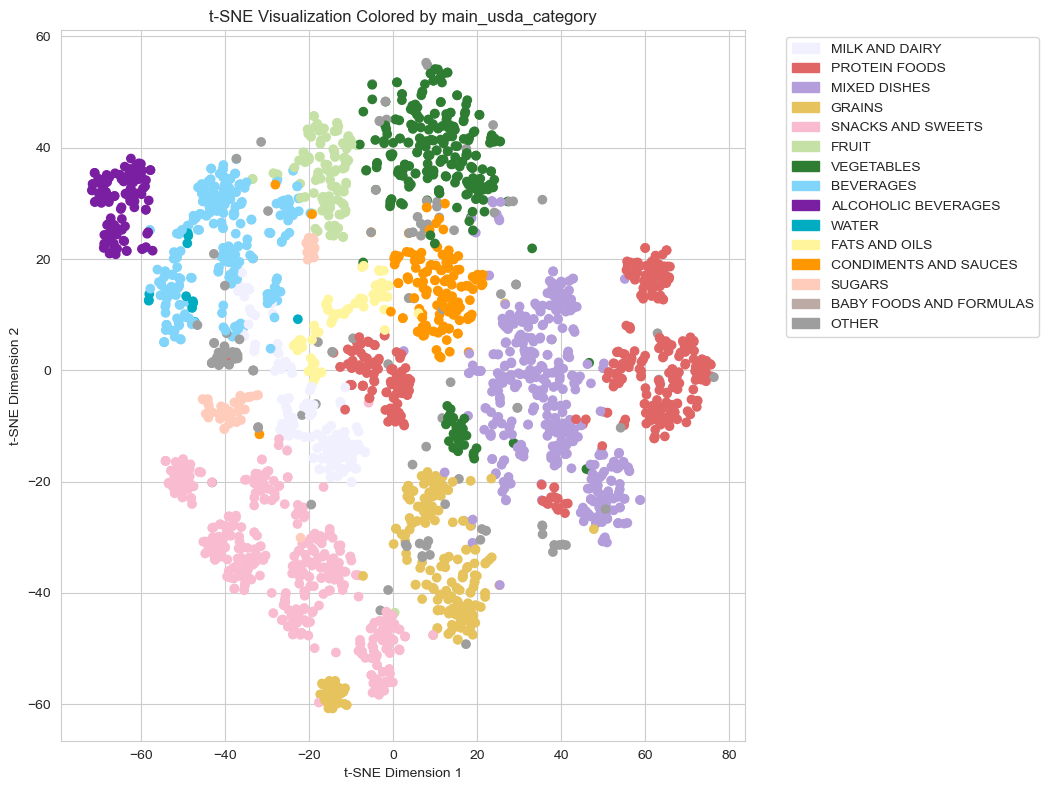

,food_name,description,serving_size,macronutrients_per_100g,micronutrients_per_100g,usda_category,ingredients,variants,item_text,embedding,tsne_1,tsne_2,main_usda_category,secondary_usda_category,third_usda_category
chocolate_cookie,Chocolate Cookie,"A sweet baked treat, typically made with flour...","{'grams': 30.0, 'household': '1 medium cookie'}","{'calories': 480.0, 'protein': 5.0, 'fat': 25....","{'calcium': 30.0, 'iron': 2.0, 'potassium': 15...","{'main_category': 'SNACKS AND SWEETS', 'second...","[Flour, Sugar, Butter, Eggs, Chocolate chips o...","[Chocolate chip cookie, Double chocolate cooki...","Chocolate Cookie A sweet baked treat, typicall...","[-0.0016493461, -0.0022579378, 0.014673492, -0...",-22.216442,-44.643646,SNACKS AND SWEETS,Sweet Bakery Products,Cookies and brownies
green_apple_amino_energy,Amino Energy Green Apple,"A green apple flavored, lightly carbonated bev...","{'grams': 9.0, 'household': '1 scoop (approxim...","{'calories': 0.0, 'protein': 0.0, 'fat': 0.0, ...","{'calcium': None, 'iron': None, 'potassium': N...","{'main_category': 'BEVERAGES', 'secondary_cate...","[Amino Blend (L-Glutamine, L-Leucine, L-Argini...","[Various flavors (e.g., Fruit Fusion, Watermel...",Amino Energy Green Apple A green apple flavore...,"[0.008850878, 0.029284129, -0.022166818, -0.05...",-50.545528,5.526571,BEVERAGES,Sweetened Beverages,Sport and energy drinks
bud_light_beer,Bud Light Beer,A light-bodied American lager known for its cr...,"{'grams': 355.0, 'household': '1 can (12 fl oz)'}","{'calories': 28.0, 'protein': 0.2, 'fat': 0.0,...","{'calcium': 2.0, 'iron': 0.01, 'potassium': 5....","{'main_category': 'ALCOHOLIC BEVERAGES', 'seco...","[Water, Barley Malt, Rice, Hops, Yeast]","[Bud Light Lime, Bud Light Platinum, Bud Light...",Bud Light Beer A light-bodied American lager k...,"[0.015487557, -0.029944913, -0.007987696, -0.0...",-66.396255,22.259583,ALCOHOLIC BEVERAGES,Alcoholic Beverages,Beer
banana_chip,Banana Chips,"Dried or dehydrated slices of bananas, often f...","{'grams': 28.0, 'household': '1/4 cup'}","{'calories': 519.0, 'protein': 2.3, 'fat': 33....","{'calcium': 17.0, 'iron': 0.7, 'potassium': 35...","{'main_category': 'FRUIT', 'secondary_category...","[Bananas, Coconut Oil, Sugar, Flavor]","[Dehydrated Banana Slices, Fried Banana Chips,...",Banana Chips Dried or dehydrated slices of ban...,"[-0.041218117, -0.020939495, -0.00084499986, -...",0.341933,-43.536167,FRUIT,Fruits,Dried fruits
oyster,"Oysters, raw",Raw oysters are a type of shellfish known for ...,"{'grams': 85.0, 'household': '6 medium oysters'}","{'calories': 81.0, 'protein': 9.4, 'fat': 2.3,...","{'calcium': 80.0, 'iron': 5.0, 'potassium': 17...","{'main_category': 'PROTEIN FOODS', 'secondary_...","[Raw oyster meat, Oyster liquor (natural juices)]","[Pacific Oyster, Eastern Oyster, Olympia Oyste...","Oysters, raw Raw oysters are a type of shellfi...","[0.040493697, 0.024074009, -0.034531366, -0.03...",57.672569,17.050524,PROTEIN FOODS,Seafood,Shellfish


In [27]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from scipy.spatial.distance import pdist, squareform

def visualize_clusters(df, embeddings_col, category_col, custom_colors, perplexity=30, n_iter=1000, random_state=42):
    """
    Performs t-SNE dimensionality reduction on embeddings and visualizes the
    clusters colored by a specified category using a custom color scheme.  It
    does *not* modify the input dataframe.

    Args:
        df (pd.DataFrame): DataFrame containing the embeddings and category data.
        embeddings_col (str): Name of the column containing the embedding vectors (numpy arrays).
        category_col (str): Name of the column containing the *already extracted* category data.
                              This should be the column containing strings such as 'SNACKS AND SWEETS'.
        custom_colors (dict): A dictionary mapping category names to color codes.
        perplexity (int): Perplexity parameter for t-SNE.
        n_iter (int): Number of iterations for t-SNE.
        random_state (int): Random state for reproducibility.

    Returns:
        pd.DataFrame: A copy of the original DataFrame with the t-SNE coordinates (tsne_1, tsne_2) added as new columns.
    """

    # 1. Prepare the data
    embeddings_array = np.vstack(df[embeddings_col].values)

    # 2. t-SNE Dimensionality Reduction
    tsne = TSNE(n_components=2, perplexity=perplexity, n_iter=n_iter, random_state=random_state)
    tsne_embeddings = tsne.fit_transform(embeddings_array)

    # 3. Add t-SNE dimensions to a *copy* of the DataFrame
    df_copy = df.copy() # copy the data frame to avoid overwriting the original
    df_copy['tsne_1'] = tsne_embeddings[:, 0]
    df_copy['tsne_2'] = tsne_embeddings[:, 1]

    print(f"t-SNE reduction complete. Shape: {tsne_embeddings.shape}")

    # 4. Create the Scatter Plot
    plt.figure(figsize=(10, 8))
    # Map the categories to colors using the custom_colors dictionary.  Handle unknown categories
    # by mapping to the generic grey used earlier.
    colors = [custom_colors.get(cat, '#9e9e9e') for cat in df_copy[category_col]]
    plt.scatter(x=df_copy['tsne_1'], y=df_copy['tsne_2'], c=colors) # Use plt.scatter directly

    plt.title("t-SNE Visualization Colored by " + category_col)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")

    # Manually create the legend
    handles = [plt.Rectangle((0,0),1,1, color=custom_colors.get(category, '#9e9e9e')) for category in custom_colors]
    plt.legend(handles, custom_colors.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')


    plt.tight_layout()
    plt.subplots_adjust(right=0.75) #Adjust the right margin to make room for the legend
    plt.show()

    return df_copy # return the dataframe with the tsne dimensions


# Example Usage:
# Assuming you have 'final_df' with 'embedding' column (numpy arrays) and 'main_usda_category' column

custom_colors = {
    'MILK AND DAIRY': '#f0f0ff', 'PROTEIN FOODS': '#e06666', 'MIXED DISHES': '#b39ddb',
    'GRAINS': '#e6c35c', 'SNACKS AND SWEETS': '#f8bbd0', 'FRUIT': '#c5e1a5',
    'VEGETABLES': '#2e7d32', 'BEVERAGES': '#81d4fa', 'ALCOHOLIC BEVERAGES': '#7b1fa2',
    'WATER': '#00acc1', 'FATS AND OILS': '#fff59d', 'CONDIMENTS AND SAUCES': '#ff9800',
    'SUGARS': '#ffccbc', 'BABY FOODS AND FORMULAS': '#bcaaa4', 'OTHER': '#9e9e9e'
}

tsne_df = visualize_clusters(final_df, 'embedding', 'main_usda_category', custom_colors)
display(tsne_df.head()) #See that tsne_1 and tsne_2 exist.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist, squareform
# No UMAP import needed
import ast

def prepare_features_for_clustering(df, embedding_col,
                                    nutrition_cols=None,
                                    categorical_cols=None,
                                    normalize_nutrition=True):
    """
    Prepares dataframe features for clustering by:
    1. Converting embedding strings to numpy arrays
    2. Normalizing nutritional data
    3. One-hot encoding categorical features
    4. Combining all features into a unified feature matrix

    Args:
        df (pd.DataFrame): DataFrame with food data
        embedding_col (str): Column name containing embeddings
        nutrition_cols (list): List of nutritional columns to include
        categorical_cols (list): List of categorical columns to one-hot encode
        normalize_nutrition (bool): Whether to normalize nutritional data

    Returns:
        tuple: (feature_matrix, feature_names, processed_df)
    """
    df_copy = df.copy()

    # 1. Process embedding column
    # Check if embeddings need to be converted from string to numpy array
    if isinstance(df_copy[embedding_col].iloc[0], str):
        df_copy[embedding_col] = df_copy[embedding_col].apply(
            lambda x: np.array(ast.literal_eval(x)) if isinstance(x, str) else x
        )

    # Get embedding dimension
    emb_dim = len(df_copy[embedding_col].iloc[0])
    print(f"Embedding dimension: {emb_dim}")

    # 2. Extract embeddings as numpy array
    embedding_matrix = np.vstack(df_copy[embedding_col].values)
    embedding_feature_names = [f"emb_{i}" for i in range(emb_dim)]

    # 3. Process nutritional features
    nutrition_matrix = None
    nutrition_feature_names = []

    if nutrition_cols:
        nutrition_data = df_copy[nutrition_cols].copy()

        # Normalize nutritional data if requested
        if normalize_nutrition:
            scaler = StandardScaler()
            nutrition_matrix = scaler.fit_transform(nutrition_data)
            # Store the scaled values back in the dataframe for later use
            scaled_nutrition = pd.DataFrame(
                nutrition_matrix,
                columns=[f"{col}_scaled" for col in nutrition_cols],
                index=df_copy.index
            )
            df_copy = pd.concat([df_copy, scaled_nutrition], axis=1)
        else:
            nutrition_matrix = nutrition_data.values

        nutrition_feature_names = nutrition_cols.copy()

    # 4. Process categorical features
    categorical_matrix = None
    categorical_feature_names = []

    if categorical_cols:
        # One-hot encode categorical features
        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        categorical_matrix = encoder.fit_transform(df_copy[categorical_cols])

        # Get the one-hot encoded feature names
        categorical_feature_names = []
        for i, col in enumerate(categorical_cols):
            categories = encoder.categories_[i]
            for cat in categories:
                categorical_feature_names.append(f"{col}_{cat}")

    # 5. Combine all features
    feature_matrices = []
    feature_names = []

    # Add embeddings
    feature_matrices.append(embedding_matrix)
    feature_names.extend(embedding_feature_names)

    # Add nutrition features if available
    if nutrition_matrix is not None:
        feature_matrices.append(nutrition_matrix)
        feature_names.extend(nutrition_feature_names)

    # Add categorical features if available
    if categorical_matrix is not None:
        feature_matrices.append(categorical_matrix)
        feature_names.extend(categorical_feature_names)

    # Combine all features into a single matrix
    combined_feature_matrix = np.hstack([m for m in feature_matrices if m is not None])

    print(f"Final feature matrix shape: {combined_feature_matrix.shape}")
    print(f"Number of feature columns: {len(feature_names)}")

    return combined_feature_matrix, feature_names, df_copy

def find_optimal_clusters(feature_matrix, method='kmeans', max_clusters=20, random_state=42):
    """
    Find optimal number of clusters using silhouette score

    Args:
        feature_matrix (np.array): Combined feature matrix
        method (str): Clustering method ('kmeans' or 'agglomerative')
        max_clusters (int): Maximum number of clusters to try
        random_state (int): Random seed

    Returns:
        tuple: (optimal_n_clusters, silhouette_scores)
    """
    silhouette_scores = []

    # Test different cluster counts
    for n_clusters in range(2, max_clusters + 1):
        print(f"Testing {n_clusters} clusters...")

        if method == 'kmeans':
            clusterer = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
        elif method == 'agglomerative':
            clusterer = AgglomerativeClustering(n_clusters=n_clusters)
        else:
            raise ValueError(f"Unsupported clustering method: {method}")

        cluster_labels = clusterer.fit_predict(feature_matrix)

        # Calculate silhouette score
        silhouette_avg = silhouette_score(feature_matrix, cluster_labels)
        silhouette_scores.append(silhouette_avg)
        print(f"Silhouette score for {n_clusters} clusters: {silhouette_avg:.4f}")

    # Find optimal number of clusters
    optimal_n_clusters = np.argmax(silhouette_scores) + 2  # +2 because we start from 2 clusters
    print(f"Optimal number of clusters: {optimal_n_clusters} (score: {max(silhouette_scores):.4f})")

    # Plot silhouette scores
    plt.figure(figsize=(10, 6))
    plt.plot(range(2, max_clusters + 1), silhouette_scores, marker='o')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Silhouette Score')
    plt.title(f'Silhouette Scores for Different Cluster Counts ({method.capitalize()})')
    plt.axvline(x=optimal_n_clusters, color='r', linestyle='--')
    plt.grid(True)
    plt.show()

    return optimal_n_clusters, silhouette_scores

def apply_clustering(feature_matrix, n_clusters, method='kmeans', random_state=42):
    """
    Apply the specified clustering algorithm

    Args:
        feature_matrix (np.array): Combined feature matrix
        n_clusters (int): Number of clusters to create
        method (str): Clustering method ('kmeans', 'agglomerative', or 'dbscan')
        random_state (int): Random seed

    Returns:
        np.array: Cluster labels
    """
    if method == 'kmeans':
        clusterer = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    elif method == 'agglomerative':
        clusterer = AgglomerativeClustering(n_clusters=n_clusters)
    elif method == 'dbscan':
        # For DBSCAN, we'll need to determine eps and min_samples
        # A simple heuristic is to use the average distance to the kth nearest neighbor
        # where k is 2 * feature_dim
        k = min(2 * feature_matrix.shape[1], feature_matrix.shape[0] - 1)
        distances = pdist(feature_matrix)
        dist_matrix = squareform(distances)
        kth_distances = np.sort(dist_matrix, axis=1)[:, k]
        eps = np.percentile(kth_distances, 90)  # 90th percentile of kth distances

        print(f"Using DBSCAN with eps={eps:.4f}, min_samples={k}")
        clusterer = DBSCAN(eps=eps, min_samples=k)
    else:
        raise ValueError(f"Unsupported clustering method: {method}")

    cluster_labels = clusterer.fit_predict(feature_matrix)

    if method == 'dbscan':
        # Count clusters (excluding noise points labeled as -1)
        n_clusters_found = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
        n_noise = list(cluster_labels).count(-1)
        print(f"DBSCAN found {n_clusters_found} clusters and {n_noise} noise points")

    return cluster_labels

def reduce_dimensions(feature_matrix, random_state=42, **kwargs):
    """
    Reduce dimensionality for visualization using t-SNE

    Args:
        feature_matrix (np.array): Combined feature matrix
        random_state (int): Random seed
        kwargs: Additional parameters for t-SNE

    Returns:
        np.array: Reduced 2D coordinates
    """
    perplexity = kwargs.get('perplexity', min(30, feature_matrix.shape[0] // 5))
    n_iter = kwargs.get('n_iter', 1000)

    reducer = TSNE(
        n_components=2,
        perplexity=perplexity,
        n_iter=n_iter,
        random_state=random_state
    )

    reduced_coords = reducer.fit_transform(feature_matrix)
    return reduced_coords

def visualize_clusters(df, x_col, y_col, cluster_col, category_col=None, custom_colors=None, title=None):
    """
    Visualize clusters with optional category coloring

    Args:
        df (pd.DataFrame): DataFrame with reduction coordinates and cluster labels
        x_col (str): Column name for x-axis
        y_col (str): Column name for y-axis
        cluster_col (str): Column name containing cluster labels
        category_col (str, optional): Column name for categorical coloring
        custom_colors (dict, optional): Custom color mapping for categories
        title (str, optional): Plot title
    """
    plt.figure(figsize=(12, 10))

    if category_col:
        # Use a specific color palette for categories
        if custom_colors:
            colors = [custom_colors.get(cat, '#9e9e9e') for cat in df[category_col]]
            scatter = plt.scatter(df[x_col], df[y_col], c=colors, alpha=0.7)

            # Create a custom legend
            legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                                          markerfacecolor=color, markersize=10)
                               for color in custom_colors.values()]
            plt.legend(legend_elements, custom_colors.keys(),
                       title=category_col, loc='upper right', bbox_to_anchor=(1.15, 1))
        else:
            # Use default category coloring
            categories = df[category_col].unique()
            palette = sns.color_palette('husl', n_colors=len(categories))
            color_map = dict(zip(categories, palette))

            for category, color in color_map.items():
                subset = df[df[category_col] == category]
                plt.scatter(subset[x_col], subset[y_col], color=color, label=category, alpha=0.7)

            plt.legend(title=category_col, loc='upper right', bbox_to_anchor=(1.15, 1))
    else:
        # Color by cluster
        clusters = sorted(df[cluster_col].unique())
        cluster_palette = sns.color_palette('husl', n_colors=len(clusters))

        for i, cluster in enumerate(clusters):
            subset = df[df[cluster_col] == cluster]
            plt.scatter(subset[x_col], subset[y_col], color=cluster_palette[i],
                        label=f'Cluster {cluster}', alpha=0.7)

        plt.legend(title='Cluster', loc='upper right', bbox_to_anchor=(1.15, 1))

    plt.title(title or f"Cluster Visualization ({x_col} vs {y_col})")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

def analyze_clusters(df, cluster_col, analyze_cols, verbose=True):
    """
    Analyze cluster characteristics

    Args:
        df (pd.DataFrame): DataFrame with cluster labels
        cluster_col (str): Column name containing cluster labels
        analyze_cols (list): Columns to analyze
        verbose (bool): Whether to print detailed results

    Returns:
        pd.DataFrame: Cluster analysis results
    """
    # Group by cluster and calculate statistics
    cluster_stats = df.groupby(cluster_col)[analyze_cols].agg(['mean', 'std', 'min', 'max', 'count'])

    if verbose:
        print(f"Cluster Analysis:")
        print(f"Number of clusters: {len(df[cluster_col].unique())}")
        print(f"Cluster sizes: {df[cluster_col].value_counts().to_dict()}")
        print("\nCluster Centroids (Means):")
        print(cluster_stats.xs('mean', axis=1, level=1))

    # For categorical columns, calculate frequencies
    categorical_cols = [col for col in analyze_cols if df[col].dtype == 'object']
    categorical_analysis = {}

    for col in categorical_cols:
        cat_freq = df.groupby([cluster_col, col]).size().unstack(fill_value=0)
        cat_pct = cat_freq.div(cat_freq.sum(axis=1), axis=0) * 100
        categorical_analysis[col] = cat_pct

        if verbose:
            print(f"\nMost common {col} in each cluster:")
            for cluster in sorted(df[cluster_col].unique()):
                subset = df[df[cluster_col] == cluster]
                top_cats = subset[col].value_counts().head(3)
                print(f"Cluster {cluster}: {dict(zip(top_cats.index, top_cats.values))}")

    return cluster_stats, categorical_analysis

def cluster_food_data(df, embedding_col, nutrition_cols=None, categorical_cols=None,
                      n_clusters=None, cluster_method='kmeans',
                      category_col=None, custom_colors=None, random_state=42):
    """
    Complete pipeline for clustering food data and visualizing results

    Args:
        df (pd.DataFrame): DataFrame with food data
        embedding_col (str): Column name containing embeddings
        nutrition_cols (list): List of nutritional columns to include
        categorical_cols (list): List of categorical columns to one-hot encode
        n_clusters (int): Number of clusters (if None, will be determined automatically)
        cluster_method (str): Clustering method ('kmeans', 'agglomerative', or 'dbscan')
        dim_reduction (str): Dimensionality reduction method ('tsne' or 'umap')
        category_col (str): Column name for categorical coloring in visualization
        custom_colors (dict): Custom color mapping for categories
        random_state (int): Random seed

    Returns:
        pd.DataFrame: DataFrame with cluster labels and reduced dimensions
    """
    # 1. Prepare features
    feature_matrix, feature_names, processed_df = prepare_features_for_clustering(
        df, embedding_col, nutrition_cols, categorical_cols
    )

    # 2. Determine optimal number of clusters if not provided
    if n_clusters is None and cluster_method != 'dbscan':
        n_clusters, _ = find_optimal_clusters(
            feature_matrix, method=cluster_method, max_clusters=min(20, len(df) // 5)
        )

    # 3. Apply clustering
    cluster_labels = apply_clustering(
        feature_matrix, n_clusters, method=cluster_method, random_state=random_state
    )

    # 4. Add cluster labels to DataFrame
    processed_df['cluster'] = cluster_labels

    # 5. Reduce dimensions for visualization with t-SNE
    reduced_coords = reduce_dimensions(
        feature_matrix, random_state=random_state
    )

    # 6. Add reduced dimensions to DataFrame
    processed_df['dim1'] = reduced_coords[:, 0]
    processed_df['dim2'] = reduced_coords[:, 1]

    # 7. Visualize clusters
    visualize_clusters(
        processed_df, 'dim1', 'dim2', 'cluster',
        category_col=category_col, custom_colors=custom_colors,
        title="Food Clusters (t-SNE visualization)"
    )

    # 8. Analyze clusters
    analysis_cols = []
    if nutrition_cols:
        analysis_cols.extend(nutrition_cols)
    if categorical_cols:
        analysis_cols.extend(categorical_cols)

    if analysis_cols:
        cluster_stats, cat_analysis = analyze_clusters(processed_df, 'cluster', analysis_cols)

    return processed_df

# Custom color palette for USDA food categories
usda_colors = {
    'MILK AND DAIRY': '#f0f0ff', 'PROTEIN FOODS': '#e06666', 'MIXED DISHES': '#b39ddb',
    'GRAINS': '#e6c35c', 'SNACKS AND SWEETS': '#f8bbd0', 'FRUIT': '#c5e1a5',
    'VEGETABLES': '#2e7d32', 'BEVERAGES': '#81d4fa', 'ALCOHOLIC BEVERAGES': '#7b1fa2',
    'WATER': '#00acc1', 'FATS AND OILS': '#fff59d', 'CONDIMENTS AND SAUCES': '#ff9800',
    'SUGARS': '#ffccbc', 'BABY FOODS AND FORMULAS': '#bcaaa4', 'OTHER': '#9e9e9e'
}

# Example usage:
"""
# Define column groups
embedding_col = 'embedding_food_name-description-usda_category'
nutrition_cols = [col for col in processed_df.columns if col.startswith('macro_') or col.startswith('micro_')]
nutrition_cols.append('serving_grams')
categorical_cols = ['main_usda_category', 'secondary_usda_category', 'third_usda_category']

# Run the clustering pipeline
clustered_df = cluster_food_data(
    processed_df,
    embedding_col=embedding_col,
    nutrition_cols=nutrition_cols,
    categorical_cols=categorical_cols,
    n_clusters=None,  # Auto-determine
    cluster_method='kmeans',
    category_col='main_usda_category',
    custom_colors=usda_colors
)
"""

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist, squareform
import ast

# Step 1: Convert embedding strings to numpy arrays
def convert_embeddings(df, embedding_col):
    """
    Convert embedding strings to numpy arrays if needed

    Args:
        df (pd.DataFrame): DataFrame with embedding column
        embedding_col (str): Name of the embedding column

    Returns:
        pd.DataFrame: DataFrame with converted embeddings
    """
    df_copy = df.copy()

    # Check if embeddings need to be converted
    if isinstance(df_copy[embedding_col].iloc[0], str):
        print("Converting embeddings from string to numpy arrays...")
        df_copy[embedding_col] = df_copy[embedding_col].apply(
            lambda x: np.array(ast.literal_eval(x)) if isinstance(x, str) else x
        )

    # Validate embeddings are numpy arrays
    sample_embedding = df_copy[embedding_col].iloc[0]
    print(f"Embedding type: {type(sample_embedding)}")
    print(f"Embedding dimension: {len(sample_embedding)}")

    return df_copy



# Custom color palette for USDA food categories
usda_colors = {
    'MILK AND DAIRY': '#f0f0ff', 'PROTEIN FOODS': '#e06666', 'MIXED DISHES': '#b39ddb',
    'GRAINS': '#e6c35c', 'SNACKS AND SWEETS': '#f8bbd0', 'FRUIT': '#c5e1a5',
    'VEGETABLES': '#2e7d32', 'BEVERAGES': '#81d4fa', 'ALCOHOLIC BEVERAGES': '#7b1fa2',
    'WATER': '#00acc1', 'FATS AND OILS': '#fff59d', 'CONDIMENTS AND SAUCES': '#ff9800',
    'SUGARS': '#ffccbc', 'BABY FOODS AND FORMULAS': '#bcaaa4', 'OTHER': '#9e9e9e'
}

# Cell 1: Define columns to use
embedding_col = 'embedding_food_name-description-usda_category'
nutrition_cols = [
    'serving_grams', 'macro_protein', 'macro_fat', 'macro_sugar', 'macro_fiber',
    'macro_saturated_fat', 'macro_carbohydrates', 'macro_calories', 'macro_sodium',
    'macro_cholesterol', 'micro_vitamin_b6', 'micro_vitamin_d', 'micro_vitamin_b12',
    'micro_vitamin_a', 'micro_calcium', 'micro_vitamin_e', 'micro_thiamin',
    'micro_vitamin_k', 'micro_folate', 'micro_selenium', 'micro_iron',
    'micro_magnesium', 'micro_vitamin_c', 'micro_phosphorus', 'micro_zinc',
    'micro_riboflavin', 'micro_niacin', 'micro_potassium'
]
categorical_cols = ['main_usda_category', 'secondary_usda_category', 'third_usda_category']

df_with_embeddings = convert_embeddings(processed_df, embedding_col)


Embedding type: <class 'numpy.ndarray'>
Embedding dimension: 768


In [22]:
# Cell 2: Convert embeddings from strings to arrays if needed


# Step 2: Normalize nutritional data
def normalize_nutrition(df, nutrition_cols):
    """
    Normalize nutritional data using StandardScaler

    Args:
        df (pd.DataFrame): DataFrame with nutritional columns
        nutrition_cols (list): List of nutritional column names

    Returns:
        tuple: (DataFrame with added scaled columns, feature matrix, column names)
    """
    df_copy = df.copy()

    # Apply StandardScaler to nutritional data
    print(f"Normalizing {len(nutrition_cols)} nutritional columns...")
    scaler = StandardScaler()
    nutrition_matrix = scaler.fit_transform(df_copy[nutrition_cols])

    # Create scaled column names and add to dataframe
    scaled_cols = [f"{col}_scaled" for col in nutrition_cols]

    # Add scaled values to dataframe
    scaled_df = pd.DataFrame(
        nutrition_matrix,
        columns=scaled_cols,
        index=df_copy.index
    )
    df_copy = pd.concat([df_copy, scaled_df], axis=1)

    print(f"Created {len(scaled_cols)} normalized columns")

    return df_copy, nutrition_matrix, scaled_cols


df_with_nutrition, nutrition_matrix, scaled_cols = normalize_nutrition(df_with_embeddings, nutrition_cols)


Normalizing 28 nutritional columns...
Created 28 normalized columns


In [23]:

# Step 3: Encode categorical data
def encode_categories(df, categorical_cols):
    """
    One-hot encode categorical columns

    Args:
        df (pd.DataFrame): DataFrame with categorical columns
        categorical_cols (list): List of categorical column names

    Returns:
        tuple: (DataFrame with categories, categorical matrix, feature names)
    """
    if not categorical_cols:
        print("No categorical columns to encode")
        return df, None, []

    print(f"One-hot encoding {len(categorical_cols)} categorical columns...")

    # One-hot encode categorical columns
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    categorical_matrix = encoder.fit_transform(df[categorical_cols])

    # Get encoded feature names
    feature_names = []
    for i, col in enumerate(categorical_cols):
        categories = encoder.categories_[i]
        for cat in categories:
            feature_names.append(f"{col}_{cat}")

    print(f"Created {len(feature_names)} one-hot encoded features")

    return df, categorical_matrix, feature_names

# Cell 3: Normalize nutritional data

df_with_categories, categorical_matrix, categorical_feature_names = encode_categories(df_with_nutrition, categorical_cols)

One-hot encoding 3 categorical columns...
Created 212 one-hot encoded features


In [24]:

# Step 4: Combine features into a unified matrix
def combine_features(df, embedding_col, scaled_nutrition_matrix=None, scaled_cols=None,
                     categorical_matrix=None, categorical_cols=None):
    """
    Combine embeddings, scaled nutritional data, and categorical data into a single feature matrix

    Args:
        df (pd.DataFrame): DataFrame with processed data
        embedding_col (str): Name of the embedding column
        scaled_nutrition_matrix (np.array): Scaled nutritional data matrix
        scaled_cols (list): Names of scaled nutritional columns
        categorical_matrix (np.array): One-hot encoded categorical data
        categorical_cols (list): Names of categorical features

    Returns:
        tuple: (Combined feature matrix, list of feature names)
    """
    # Extract embeddings
    print(f"Extracting embeddings from {embedding_col}...")
    embedding_matrix = np.vstack(df[embedding_col].values)
    emb_dim = embedding_matrix.shape[1]
    embedding_feature_names = [f"emb_{i}" for i in range(emb_dim)]

    # Prepare to combine features
    feature_matrices = [embedding_matrix]
    feature_names = embedding_feature_names.copy()

    # Add nutritional features if available
    if scaled_nutrition_matrix is not None and scaled_cols is not None:
        print(f"Adding {scaled_nutrition_matrix.shape[1]} nutritional features...")
        feature_matrices.append(scaled_nutrition_matrix)
        feature_names.extend(scaled_cols)

    # Add categorical features if available
    if categorical_matrix is not None and categorical_cols is not None:
        print(f"Adding {len(categorical_cols)} categorical features...")
        feature_matrices.append(categorical_matrix)
        feature_names.extend(categorical_cols)

    # Combine all features
    combined_matrix = np.hstack(feature_matrices)

    print(f"Created combined feature matrix with shape: {combined_matrix.shape}")
    print(f"Total features: {len(feature_names)}")

    return combined_matrix, feature_names

# Cell 4: Encode categorical features
combined_features, feature_names = combine_features(
    df_with_categories,
    embedding_col,
    nutrition_matrix,
    scaled_cols,
    categorical_matrix,
    categorical_feature_names
)


Extracting embeddings from embedding_food_name-description-usda_category...
Adding 28 nutritional features...
Adding 212 categorical features...
Created combined feature matrix with shape: (2661, 1008)
Total features: 1008


In [68]:
combined_features.shape

(2661, 1008)

Finding optimal number of clusters (testing 2 to 15)...
Testing 2 clusters... Silhouette score: 0.5060
Testing 3 clusters... Silhouette score: 0.2292
Testing 4 clusters... Silhouette score: 0.1644
Testing 5 clusters... Silhouette score: 0.2043
Testing 6 clusters... Silhouette score: 0.2040
Testing 7 clusters... Silhouette score: 0.2058
Testing 8 clusters... Silhouette score: 0.0932
Testing 9 clusters... Silhouette score: 0.2107
Testing 10 clusters... Silhouette score: 0.1205
Testing 11 clusters... Silhouette score: 0.1393
Testing 12 clusters... Silhouette score: 0.1348
Testing 13 clusters... Silhouette score: 0.1422
Testing 14 clusters... Silhouette score: 0.1290
Testing 15 clusters... Silhouette score: 0.1493
Optimal number of clusters: 2 (score: 0.5060)


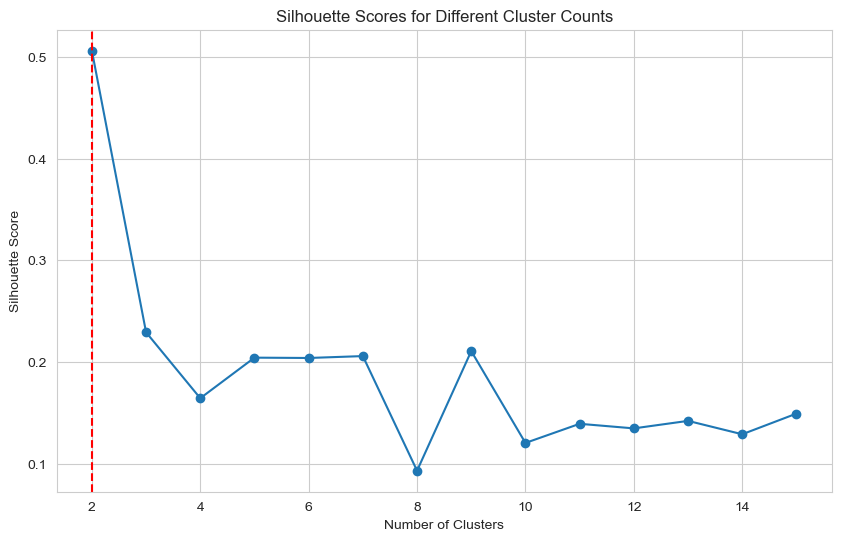

In [26]:

# Step 5: Find optimal number of clusters
def find_optimal_clusters(feature_matrix, max_clusters=20, random_state=42):
    """
    Find optimal number of clusters using silhouette score

    Args:
        feature_matrix (np.array): Combined feature matrix
        max_clusters (int): Maximum number of clusters to try
        random_state (int): Random seed

    Returns:
        tuple: (optimal_n_clusters, silhouette_scores)
    """
    silhouette_scores = []
    max_clusters = min(max_clusters, feature_matrix.shape[0] // 5)

    print(f"Finding optimal number of clusters (testing 2 to {max_clusters})...")

    # Test different cluster counts
    for n_clusters in range(2, max_clusters + 1):
        print(f"Testing {n_clusters} clusters...", end="")

        clusterer = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
        cluster_labels = clusterer.fit_predict(feature_matrix)

        # Calculate silhouette score
        silhouette_avg = silhouette_score(feature_matrix, cluster_labels)
        silhouette_scores.append(silhouette_avg)
        print(f" Silhouette score: {silhouette_avg:.4f}")

    # Find optimal number of clusters
    optimal_n_clusters = np.argmax(silhouette_scores) + 2  # +2 because we start from 2 clusters
    print(f"Optimal number of clusters: {optimal_n_clusters} (score: {max(silhouette_scores):.4f})")

    # Plot silhouette scores
    plt.figure(figsize=(10, 6))
    plt.plot(range(2, max_clusters + 1), silhouette_scores, marker='o')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Silhouette Score')
    plt.title('Silhouette Scores for Different Cluster Counts')
    plt.axvline(x=optimal_n_clusters, color='r', linestyle='--')
    plt.grid(True)
    plt.show()

    return optimal_n_clusters, silhouette_scores

# Cell 5: Combine all features

optimal_clusters, silhouette_scores = find_optimal_clusters(combined_features, max_clusters=15)

In [27]:

# Step 6: Apply clustering algorithm
def apply_kmeans_clustering(feature_matrix, n_clusters, random_state=42):
    """
    Apply KMeans clustering

    Args:
        feature_matrix (np.array): Combined feature matrix
        n_clusters (int): Number of clusters
        random_state (int): Random seed

    Returns:
        tuple: (cluster labels, clusterer)
    """
    print(f"Applying KMeans clustering with {n_clusters} clusters...")

    clusterer = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    cluster_labels = clusterer.fit_predict(feature_matrix)

    # Count samples per cluster
    unique_clusters, counts = np.unique(cluster_labels, return_counts=True)
    for cluster, count in zip(unique_clusters, counts):
        print(f"Cluster {cluster}: {count} samples")

    return cluster_labels, clusterer

# Cell 6: Find optimal number of clusters
optimal_clusters = 9
cluster_labels, kmeans_model = apply_kmeans_clustering(combined_features, optimal_clusters)

Applying KMeans clustering with 9 clusters...
Cluster 0: 445 samples
Cluster 1: 591 samples
Cluster 2: 1 samples
Cluster 3: 1333 samples
Cluster 4: 1 samples
Cluster 5: 43 samples
Cluster 6: 101 samples
Cluster 7: 3 samples
Cluster 8: 143 samples


Applying DBSCAN clustering with eps=0.1, min_samples=10...
Estimated number of clusters: 53
Estimated number of noise points: 1075
Noise: 1075 samples
Cluster 0: 78 samples
Cluster 1: 79 samples
Cluster 2: 60 samples
Cluster 3: 22 samples
Cluster 4: 26 samples
Cluster 5: 11 samples
Cluster 6: 79 samples
Cluster 7: 42 samples
Cluster 8: 11 samples
Cluster 9: 39 samples
Cluster 10: 51 samples
Cluster 11: 43 samples
Cluster 12: 62 samples
Cluster 13: 125 samples
Cluster 14: 22 samples
Cluster 15: 100 samples
Cluster 16: 13 samples
Cluster 17: 24 samples
Cluster 18: 33 samples
Cluster 19: 20 samples
Cluster 20: 13 samples
Cluster 21: 15 samples
Cluster 22: 10 samples
Cluster 23: 31 samples
Cluster 24: 18 samples
Cluster 25: 20 samples
Cluster 26: 15 samples
Cluster 27: 28 samples
Cluster 28: 14 samples
Cluster 29: 70 samples
Cluster 30: 67 samples
Cluster 31: 22 samples
Cluster 32: 11 samples
Cluster 33: 36 samples
Cluster 34: 22 samples
Cluster 35: 31 samples
Cluster 36: 12 samples
Cluste

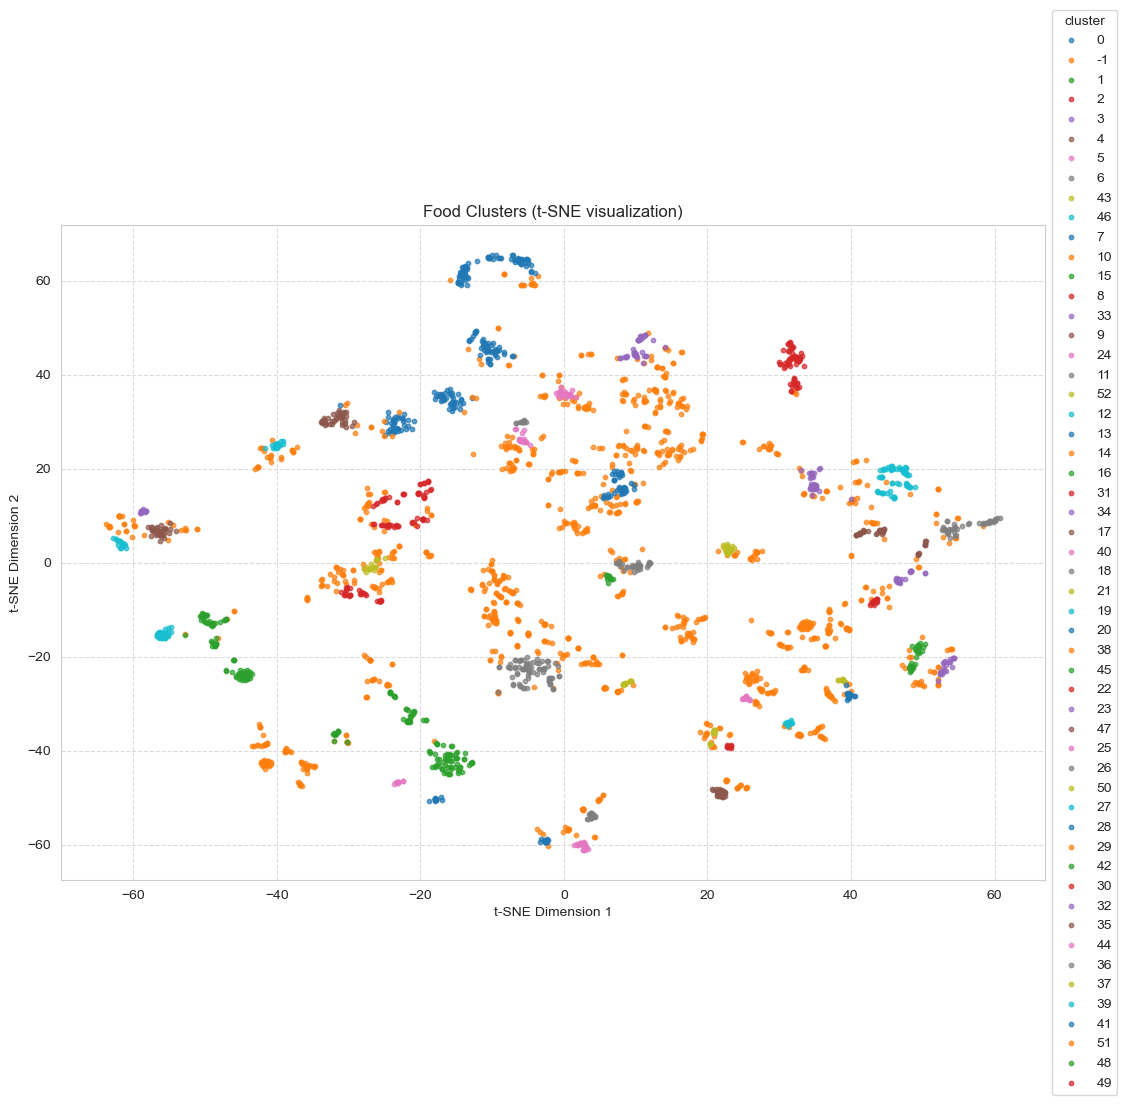

In [86]:
# Cell 7: Apply DBSCAN clustering
from sklearn.cluster import DBSCAN
import numpy as np

def apply_dbscan_clustering(feature_matrix, eps=0.5, min_samples=5):
    """
    Apply DBSCAN clustering. Finds core samples of high density and expands clusters from them.
    Good for arbitrarily shaped clusters and handles noise.

    Args:
        feature_matrix (np.array): Combined feature matrix.
        eps (float): The maximum distance between two samples for one to be considered
                     as in the neighborhood of the other. Needs tuning.
        min_samples (int): The number of samples in a neighborhood for a point to be
                           considered as a core point. Needs tuning.

    Returns:
        tuple: (cluster labels, clusterer object)
               Note: Noise points are assigned the label -1.
    """
    print(f"Applying DBSCAN clustering with eps={eps}, min_samples={min_samples}...")

    clusterer = DBSCAN(eps=eps, min_samples=min_samples, metric='cosine') # Using cosine for high-dim data
    cluster_labels = clusterer.fit_predict(feature_matrix)

    # Calculate number of clusters, ignoring noise (-1)
    unique_clusters = set(cluster_labels)
    n_clusters_ = len(unique_clusters) - (1 if -1 in unique_clusters else 0)
    n_noise_ = list(cluster_labels).count(-1)

    print(f'Estimated number of clusters: {n_clusters_}')
    print(f'Estimated number of noise points: {n_noise_}')

    # Count samples per cluster
    unique, counts = np.unique(cluster_labels, return_counts=True)
    for cluster, count in zip(unique, counts):
        label = "Noise" if cluster == -1 else f"Cluster {cluster}"
        print(f"{label}: {count} samples")

    return cluster_labels, clusterer

# --- Example Usage (tune eps and min_samples based on your data) ---
# You'll likely need to experiment with eps and min_samples.
# Start by maybe scaling features if not already done appropriately for distance calcs,
# or use 'cosine' metric which is often better for high-dimensional embeddings.
# Example values (likely need adjustment):
dbscan_labels, dbscan_model = apply_dbscan_clustering(combined_features, eps=0.1, min_samples=10)
# dbscan_labels, dbscan_model = apply_dbscan_clustering(combined_features, eps=0.5, min_samples=10) # If using cosine/normalized data

# Note: Finding optimal eps might involve techniques like k-distance graphs.

result_df = add_results_to_df(df_with_categories, dbscan_labels, tsne_result)
result_df['cluster'].value_counts()
visualize_clusters(result_df, category_col='cluster', point_size=10)

In [77]:
# Cell 8: Apply HDBSCAN clustering
# Note: You might need to install hdbscan: pip install hdbscan
import hdbscan
import numpy as np

def apply_hdbscan_clustering(feature_matrix, min_cluster_size=5, min_samples=None, metric='euclidean'):
    """
    Apply HDBSCAN clustering. More robust than DBSCAN, finds varying density clusters.

    Args:
        feature_matrix (np.array): Combined feature matrix.
        min_cluster_size (int): The minimum size of clusters; single linkage splits points
                                  below this size into outliers. Key parameter to tune.
        min_samples (int): The number of samples in a neighbourhood for a point to be
                           considered a core point. Defaults to min_cluster_size.
        metric (str): The distance metric to use (e.g., 'euclidean', 'manhattan', 'cosine').
                      'cosine' or 'euclidean' on normalized data often works well.

    Returns:
        tuple: (cluster labels, clusterer object)
               Note: Noise points are assigned the label -1.
    """
    print(f"Applying HDBSCAN clustering with min_cluster_size={min_cluster_size}...")

    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size,
                                min_samples=min_samples, # Often left as None (defaults to min_cluster_size)
                                metric=metric,
                                cluster_selection_method='eom') # 'eom' often better than 'leaf'
    cluster_labels = clusterer.fit_predict(feature_matrix)

    # Calculate number of clusters, ignoring noise (-1)
    unique_clusters = set(cluster_labels)
    n_clusters_ = len(unique_clusters) - (1 if -1 in unique_clusters else 0)
    n_noise_ = list(cluster_labels).count(-1)

    print(f'Estimated number of clusters: {n_clusters_}')
    print(f'Estimated number of noise points: {n_noise_}')

    # # Count samples per cluster
    # unique, counts = np.unique(cluster_labels, return_counts=True)
    # for cluster, count in zip(unique, counts):
    #     label = "Noise" if cluster == -1 else f"Cluster {cluster}"
    #     print(f"{label}: {count} samples")

    return cluster_labels, clusterer

# --- Example Usage (tune min_cluster_size) ---
# Adjust min_cluster_size based on expected smallest meaningful group size.
# Use 'cosine' metric if dealing with high-dim sparse or embedding data.
# hdbscan_labels, hdbscan_model = apply_hdbscan_clustering(combined_features, min_cluster_size=10, metric='cosine')
hdbscan_labels, hdbscan_model = apply_hdbscan_clustering(combined_features, min_cluster_size=10, metric='euclidean') # If data appropriately scaled


result_df = add_results_to_df(df_with_categories, hdbscan_labels, tsne_result)


Applying HDBSCAN clustering with min_cluster_size=10...


/Users/vince/miniforge3/envs/ds/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/vince/miniforge3/envs/ds/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Estimated number of clusters: 51
Estimated number of noise points: 855
Added 'cluster', 'tsne_1', and 'tsne_2' columns to DataFrame


,food_name,description,serving_size,macronutrients_per_100g,micronutrients_per_100g,usda_category,ingredients,variants,item_text,embedding_food_name-description-usda_category,...,micro_magnesium_scaled,micro_vitamin_c_scaled,micro_phosphorus_scaled,micro_zinc_scaled,micro_riboflavin_scaled,micro_niacin_scaled,micro_potassium_scaled,cluster,tsne_1,tsne_2
chocolate_cookie,Chocolate Cookie,"A sweet baked treat, typically made with flour, sugar, butter, eggs, and chocolate or chocolate flavoring. Variations include different types of chocolate, nuts, and fillings.","{'grams': 30.0, 'household': '1 medium cookie'}","{'calories': 480.0, 'protein': 5.0, 'fat': 25.0, 'carbohydrates': 60.0, 'fiber': 2.0, 'sugar': 30.0, 'saturated_fat': 15.0, 'cholesterol': 50.0, 'sodium': 250.0}","{'calcium': 30.0, 'iron': 2.0, 'potassium': 150.0, 'vitamin_a': 50.0, 'vitamin_c': 0.0, 'vitamin_d': 0.0, 'vitamin_e': 0.5, 'vitamin_k': 2.0, 'thiamin': 0.1, 'riboflavin': 0.1, 'niacin': 0.5, 'vitamin_b6': 0.05, 'folate': 15.0, 'vitamin_b12': 0.0, 'phosphorus': 80.0, 'magnesium': 20.0, 'zinc': 0.5, 'selenium': 5.0}","{'main_category': 'SNACKS AND SWEETS', 'secondary_category': 'Sweet Bakery Products', 'third_category': 'Cookies and brownies'}","[Flour, Sugar, Butter, Eggs, Chocolate chips or cocoa powder, Vanilla extract, Baking soda, Salt]","[Chocolate chip cookie, Double chocolate cookie, Chocolate fudge cookie, Peanut butter chocolate cookie, Vegan chocolate cookie, Gluten-free chocolate cookie]","Chocolate Cookie A sweet baked treat, typically made with flour, sugar, butter, eggs, and chocolate or chocolate flavoring. Variations include different types of chocolate, nuts, and fillings. {'main_category': 'SNACKS AND SWEETS', 'secondary_category': 'Sweet Bakery Products', 'third_category': 'Cookies and brownies'}","[-0.0016493461, -0.0022579378, 0.014673492, -0.036414444, -0.0050175395, 0.032184966, 0.053150084, -0.017862089, 0.010734286, 0.06466358, 0.020729544, 0.0928003, 0.0016659973, -0.007144895, 0.060359787, -0.06456118, -0.0026356345, 0.012930851, -0.03573923, -0.06050175, 0.06079137, -0.004927367, 0.026466282, 0.0009492485, -0.05903584, -0.05160248, -0.007552473, 0.00056131964, 0.02965983, -0.010781803, 0.058477014, 0.05980542, -0.00277391, -0.01249876, -0.023863124, -0.040276606, -0.025650509, -0.042989247, 0.04071045, -0.031686604, 0.004741523, -0.010153099, -0.04602683, 0.032150142, -0.031177195, 0.023501527, -0.01640229, -0.011959042, 0.007440449, 0.029075515, 0.060053207, 0.026774079, 0.0267478, 0.041013915, -0.01845584, -0.07728085, -0.036340836, -0.016678901, 0.017157326, -0.036969565, 0.015746145, -0.047646914, -0.0050053834, -0.039377015, -0.009499458, -0.008970837, 0.0048517045, -0.012268206, -0.04533659, 0.0068607344, -0.0857763, 0.04932364, -0.037601817, -0.019163752, 0.015866987, -0.074471, 0.020232832, -0.0053661703, 0.09140799, 0.0024548075, -0.02101821, 0.015113025, 0.055989046, 0.022063533, 0.038932063, 0.008392719, -0.008176897, -0.020491393, -0.07651612, -0.005875464, 0.011496698, 0.030553827, 0.0068174475, 0.014657358, 0.047794495, -0.00898989, -0.04760888, -0.11671793, 0.026250651, 0.05111716, ...]",...,-0.177945,-0.093555,-0.268127,-0.233618,-0.062182,-0.132270,-0.304819,44,-17.086496,35.827583
green_apple_amino_energy,Amino Energy Green Apple,"A green apple flavored, lightly carbonated beverage marketed as a pre-workout or energy drink, containing amino acids, caffeine, and electrolytes.","{'grams': 9.0, 'household': '1 scoop (approximate)'}","{'calories': 0.0, 'protein': 0.0, 'fat': 0.0, 'carbohydrates': 0.0, 'fiber': 0.0, 'sugar': 0.0, 'saturated_fat': None, 'cholesterol': None, 'sodium': 0.0}","{'calcium': None, 'iron': None, 'potassium': None, 'vitamin_a': None, 'vitamin_c': None, 'vitamin_d': None, 'vitamin_e': None, 'vitamin_k': None, 'thiamin': None, 'riboflavin': None, 'niacin': None, 'vitamin_b6': None, 'folate': None, 'vitamin_b12': None, 'phosphorus': None, 'magnesium': None, 'zinc': None, 'selenium': None}","{'main

In [78]:
result_df['cluster'].value_counts()

cluster
-1     855
 7      99
 5      93
 21     77
 41     76
 49     76
 36     64
 13     63
 2      60
 24     53
 47     51
 39     46
 28     40
 38     40
 42     38
 17     38
 4      38
 46     37
 31     35
 44     35
 40     35
 14     34
 43     34
 34     33
 35     33
 18     33
 6      32
 45     32
 12     32
 8      30
 9      30
 11     29
 10     28
 26     27
 15     26
 16     26
 37     25
 33     22
 25     22
 19     21
 50     21
 29     19
 3      15
 23     14
 1      14
 20     14
 22     12
 48     12
 30     11
 0      11
 32     10
 27     10
Name: count, dtype: int64

In [92]:
# Cell 9: Apply Mean Shift clustering
from sklearn.cluster import MeanShift, estimate_bandwidth
import numpy as np

def apply_mean_shift_clustering(feature_matrix, quantile=0.2, n_samples=None, random_state=42):
    """
    Apply Mean Shift clustering. Finds clusters by locating density modes.
    Number of clusters is determined automatically based on the bandwidth.

    Args:
        feature_matrix (np.array): Combined feature matrix.
        quantile (float): Quantile for estimating bandwidth. Lower values find more clusters.
                          Needs tuning. Can be slow to estimate.
        n_samples (int): Number of samples to use for bandwidth estimation. None uses all.
                         Reducing this speeds up bandwidth estimation but makes it less accurate.
        random_state (int): Random seed for bandwidth estimation sampling.

    Returns:
        tuple: (cluster labels, clusterer object)
    """
    print("Estimating bandwidth for Mean Shift...")
    # Bandwidth estimation can be slow on large datasets. Consider reducing n_samples.
    # Or manually set bandwidth if estimate_bandwidth is too slow or gives poor results.
    bandwidth = estimate_bandwidth(feature_matrix,
                                   quantile=quantile,
                                   n_samples=n_samples,
                                   random_state=random_state,
                                   n_jobs=-1) # Use all CPU cores

    if bandwidth == 0: # Handle case where bandwidth estimation fails (e.g., duplicate points)
        print("Warning: Estimated bandwidth is 0. Mean Shift may not work well.")
        bandwidth = 1.0 # Set a default small bandwidth

    print(f"Applying Mean Shift clustering with estimated bandwidth={bandwidth:.3f}...")

    # Use bin_seeding=True for potentially faster computation
    clusterer = MeanShift(bandwidth=bandwidth, bin_seeding=True, n_jobs=-1)
    # MeanShift doesn't have fit_predict, so use fit then access labels
    clusterer.fit(feature_matrix)
    cluster_labels = clusterer.labels_

    unique_clusters = np.unique(cluster_labels)
    n_clusters_ = len(unique_clusters)

    print(f'Estimated number of clusters: {n_clusters_}')

    # Count samples per cluster
    unique, counts = np.unique(cluster_labels, return_counts=True)
    for cluster, count in zip(unique, counts):
        print(f"Cluster {cluster}: {count} samples")

    return cluster_labels, clusterer

# --- Example Usage (tune quantile or set bandwidth manually) ---
# Adjust quantile (lower values -> more clusters) or provide a fixed bandwidth.
# Bandwidth estimation is the main challenge here.
# ms_labels, ms_model = apply_mean_shift_clustering(combined_features, quantile=0.1, n_samples=500)
ms_labels, ms_model = apply_mean_shift_clustering(combined_features, quantile=0.1, n_samples=1000)
# Alternative: Set bandwidth manually if estimation is poor or too slow
# ms_labels, ms_model = apply_mean_shift_clustering(combined_features, quantile=None) # This would skip estimation, need manual bandwidth in MeanShift()

Estimating bandwidth for Mean Shift...
Applying Mean Shift clustering with estimated bandwidth=4.233...
Estimated number of clusters: 28
Cluster 0: 2301 samples
Cluster 1: 71 samples
Cluster 2: 31 samples
Cluster 3: 22 samples
Cluster 4: 29 samples
Cluster 5: 64 samples
Cluster 6: 5 samples
Cluster 7: 18 samples
Cluster 8: 2 samples
Cluster 9: 2 samples
Cluster 10: 8 samples
Cluster 11: 2 samples
Cluster 12: 15 samples
Cluster 13: 6 samples
Cluster 14: 2 samples
Cluster 15: 4 samples
Cluster 16: 1 samples
Cluster 17: 2 samples
Cluster 18: 1 samples
Cluster 19: 3 samples
Cluster 20: 27 samples
Cluster 21: 18 samples
Cluster 22: 2 samples
Cluster 23: 11 samples
Cluster 24: 7 samples
Cluster 25: 5 samples
Cluster 26: 1 samples
Cluster 27: 1 samples


In [28]:
cluster_labels

array([1, 3, 3, ..., 1, 1, 3], shape=(2661,), dtype=int32)

In [65]:

# Step 7: Apply t-SNE dimensionality reduction
def apply_tsne(feature_matrix, random_state=42, perplexity=30, n_iter=1000):
    """
    Apply t-SNE dimensionality reduction

    Args:
        feature_matrix (np.array): Combined feature matrix
        random_state (int): Random seed
        perplexity (int): Perplexity parameter for t-SNE
        n_iter (int): Number of iterations

    Returns:
        np.array: 2D coordinates from t-SNE
    """
    # Adjust perplexity if needed (should be smaller than n_samples - 1)
    perplexity = min(perplexity, feature_matrix.shape[0] // 5)

    print(f"Applying t-SNE with perplexity={perplexity}, n_iter={n_iter}...")
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        n_iter=n_iter,
        random_state=random_state
    )

    tsne_result = tsne.fit_transform(feature_matrix)
    print(f"t-SNE complete. Output shape: {tsne_result.shape}")

    return tsne_result


# Cell 8: Apply t-SNE for visualization
tsne_result = apply_tsne(combined_features, perplexity=30)


Applying t-SNE with perplexity=30, n_iter=1000...


/Users/vince/miniforge3/envs/ds/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE complete. Output shape: (2661, 2)


In [71]:

# Step 8: Add cluster labels and t-SNE coordinates to DataFrame
def add_results_to_df(df, cluster_labels, tsne_coords, cluster_col='cluster'):
    """
    Add cluster labels and t-SNE coordinates to DataFrame

    Args:
        df (pd.DataFrame): Original DataFrame
        cluster_labels (np.array): Cluster assignments
        tsne_coords (np.array): t-SNE coordinates

    Returns:
        pd.DataFrame: DataFrame with added columns
    """
    df_copy = df.copy()

    # Add cluster labels
    df_copy[cluster_col] = cluster_labels

    # Add t-SNE coordinates
    df_copy['tsne_1'] = tsne_coords[:, 0]
    df_copy['tsne_2'] = tsne_coords[:, 1]

    print(f"Added 'cluster', 'tsne_1', and 'tsne_2' columns to DataFrame")

    return df_copy

result_df = add_results_to_df(df_with_categories, cluster_labels, tsne_result)

Added 'cluster', 'tsne_1', and 'tsne_2' columns to DataFrame


In [96]:
# Cell (e.g., Cell 10): Apply HDBSCAN clustering on t-SNE coordinates
import hdbscan
import numpy as np
import pandas as pd

def apply_hdbscan_on_tsne(df, tsne_cols=['tsne_1', 'tsne_2'], min_cluster_size=5, min_samples=None, metric='euclidean'):
    """
    Apply HDBSCAN clustering specifically on t-SNE coordinates.

    Args:
        df (pd.DataFrame): DataFrame containing the t-SNE coordinates.
        tsne_cols (list): List of column names for the t-SNE dimensions (e.g., ['tsne_1', 'tsne_2']).
        min_cluster_size (int): The minimum size of clusters. Key parameter to tune.
                                  Smaller values allow detection of smaller clusters.
        min_samples (int): The number of samples in a neighbourhood for a point to be
                           considered a core point. Defaults to min_cluster_size. Adjusting
                           can sometimes help refine clusters, especially in noisy data.
        metric (str): The distance metric to use. 'euclidean' is standard for t-SNE.

    Returns:
        tuple: (cluster labels (np.array), clusterer object)
               Note: Noise points are assigned the label -1.
    """
    if not all(col in df.columns for col in tsne_cols):
        raise ValueError(f"DataFrame must contain columns: {tsne_cols}")

    tsne_coordinates = df[tsne_cols].values
    print(f"Applying HDBSCAN clustering on {tsne_coordinates.shape[0]} points in 2D t-SNE space...")
    print(f"Parameters: min_cluster_size={min_cluster_size}, min_samples={min_samples or min_cluster_size}, metric='{metric}'")

    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size,
                                min_samples=min_samples,
                                metric=metric,
                                cluster_selection_method='eom', # Excess of Mass - generally good
                                gen_min_span_tree=True) # Useful for visualization/analysis if needed

    cluster_labels = clusterer.fit_predict(tsne_coordinates)

    # Summarize results
    unique_clusters = set(cluster_labels)
    n_clusters_ = len(unique_clusters) - (1 if -1 in unique_clusters else 0)
    n_noise_ = list(cluster_labels).count(-1)

    print(f'Estimated number of clusters: {n_clusters_}')
    print(f'Estimated number of noise points: {n_noise_}')

    unique, counts = np.unique(cluster_labels, return_counts=True)
    print("Cluster counts:")
    for cluster, count in zip(unique, counts):
        label = "Noise (-1)" if cluster == -1 else f"Cluster {cluster}"
        print(f"  {label}: {count} samples")

    return cluster_labels, clusterer

# --- Example Usage (Tune min_cluster_size primarily) ---
# Start with a small min_cluster_size if you expect very small groups
tsne_hdbscan_labels, tsne_hdbscan_model = apply_hdbscan_on_tsne(result_df, min_cluster_size=5)

# Try increasing it if you get too many small, potentially insignificant clusters
# tsne_hdbscan_labels, tsne_hdbscan_model = apply_hdbscan_on_tsne(result_df, min_cluster_size=15)

# If you have result_df defined:
# You would run something like:
# hdbscan_labels_tsne, hdbscan_model_tsne = apply_hdbscan_on_tsne(result_df, min_cluster_size=10)
# result_df['hdbscan_cluster_tsne'] = hdbscan_labels_tsne # Add labels to df

Applying HDBSCAN clustering on 2661 points in 2D t-SNE space...
Parameters: min_cluster_size=5, min_samples=5, metric='euclidean'
Estimated number of clusters: 145
Estimated number of noise points: 294
Cluster counts:
  Noise (-1): 294 samples
  Cluster 0: 40 samples
  Cluster 1: 17 samples
  Cluster 2: 7 samples
  Cluster 3: 18 samples
  Cluster 4: 45 samples
  Cluster 5: 11 samples
  Cluster 6: 7 samples
  Cluster 7: 15 samples
  Cluster 8: 6 samples
  Cluster 9: 36 samples
  Cluster 10: 7 samples
  Cluster 11: 11 samples
  Cluster 12: 20 samples
  Cluster 13: 30 samples
  Cluster 14: 14 samples
  Cluster 15: 12 samples
  Cluster 16: 25 samples
  Cluster 17: 13 samples
  Cluster 18: 33 samples
  Cluster 19: 10 samples
  Cluster 20: 7 samples
  Cluster 21: 21 samples
  Cluster 22: 8 samples
  Cluster 23: 13 samples
  Cluster 24: 66 samples
  Cluster 25: 35 samples
  Cluster 26: 6 samples
  Cluster 27: 11 samples
  Cluster 28: 7 samples
  Cluster 29: 6 samples
  Cluster 30: 31 samples


/Users/vince/miniforge3/envs/ds/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/vince/miniforge3/envs/ds/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Visualizing clusters colored by main_usda_category...


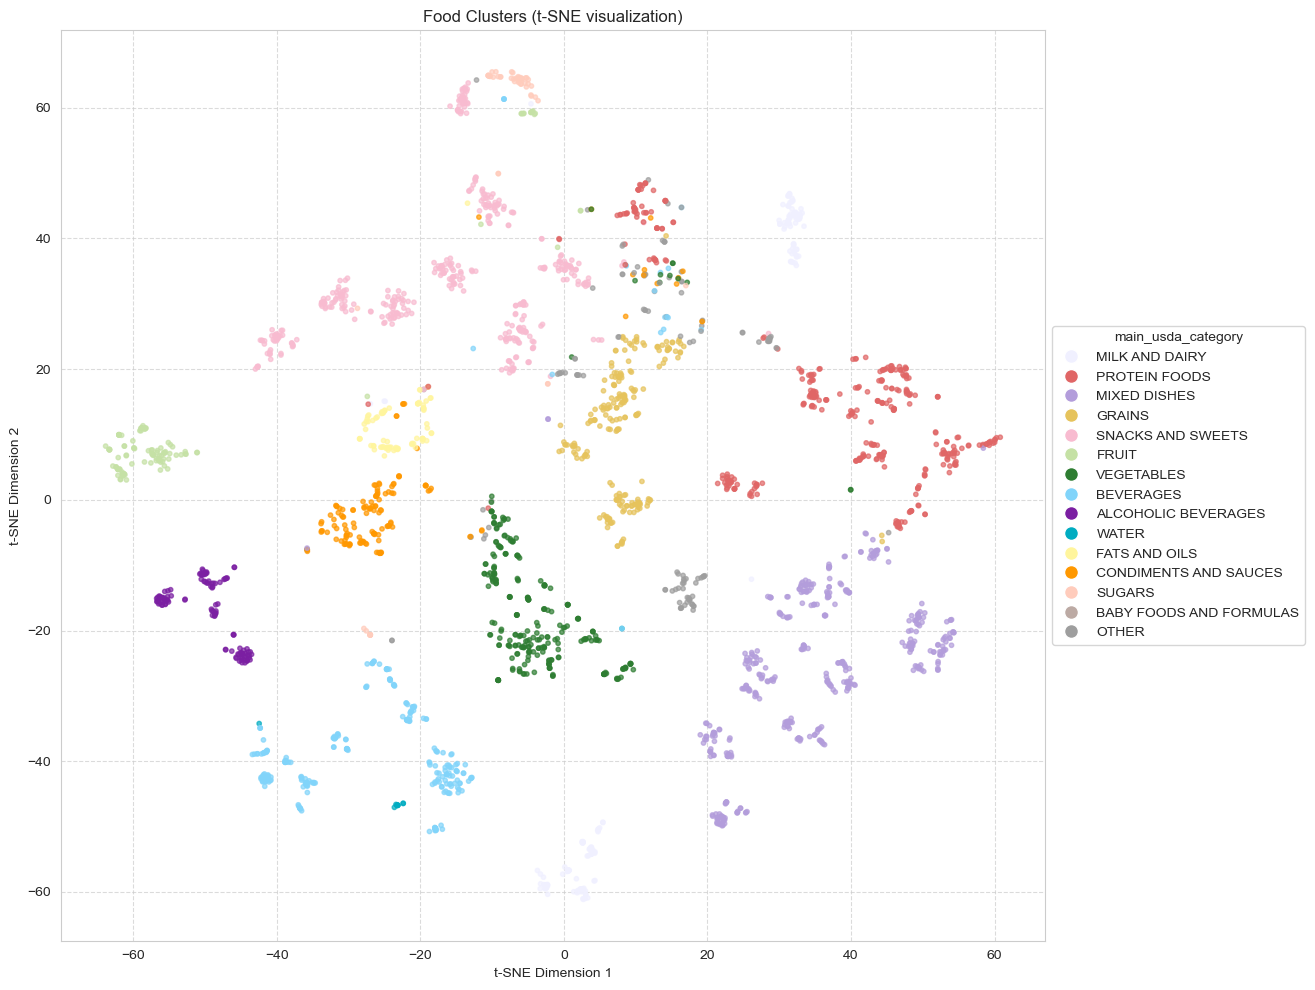

In [97]:
# Step 9: Visualize clusters with color coding
def visualize_clusters(df, category_col=None, custom_colors=None, point_size=30):
    """
    Visualize clusters with optional category coloring

    Args:
        df (pd.DataFrame): DataFrame with cluster and t-SNE columns
        category_col (str): Name of categorical column for coloring
        custom_colors (dict): Dictionary mapping categories to colors
        point_size (int): Size of the dots in the scatter plot
    """
    # Create figure with two subplots - one for the plot, one for the legend
    fig = plt.figure(figsize=(14, 10))

    # Create a larger subplot for the scatter plot
    scatter_ax = fig.add_subplot(111)

    if category_col and category_col in df.columns:
        print(f"Visualizing clusters colored by {category_col}...")

        # Use custom colors if provided
        if custom_colors:
            colors = [custom_colors.get(cat, '#9e9e9e') for cat in df[category_col]]
            scatter_ax.scatter(df['tsne_1'], df['tsne_2'], c=colors, alpha=0.7, s=point_size)

            # Create a separate legend outside the plot
            handles = [plt.Line2D([0], [0], marker='o', color='w',
                                  markerfacecolor=color, markersize=10)
                       for color in custom_colors.values()]
            legend = scatter_ax.legend(handles, custom_colors.keys(),
                                       title=category_col, loc='center left', bbox_to_anchor=(1.0, 0.5))

        else:
            # Use default category coloring
            categories = df[category_col].unique()
            for category in categories:
                subset = df[df[category_col] == category]
                scatter_ax.scatter(subset['tsne_1'], subset['tsne_2'], label=category, alpha=0.7, s=point_size)

            legend = scatter_ax.legend(title=category_col, loc='center left', bbox_to_anchor=(1.0, 0.5))
    else:
        print("Visualizing clusters...")
        # Color by cluster
        scatter_ax.scatter(df['tsne_1'], df['tsne_2'], c=df['cluster'], cmap='tab10', alpha=0.7, s=point_size)

    scatter_ax.set_title("Food Clusters (t-SNE visualization)")
    scatter_ax.set_xlabel("t-SNE Dimension 1")
    scatter_ax.set_ylabel("t-SNE Dimension 2")
    scatter_ax.grid(True, linestyle='--', alpha=0.7)

    # Adjust layout to make room for the legend
    plt.tight_layout()
    plt.subplots_adjust(right=0.75)  # Reserve space on the right for the legend

    plt.show()
# Cell 9: Add results to DataFrame

# 30
visualize_clusters(result_df, category_col='main_usda_category', custom_colors=usda_colors, point_size=10)

In [133]:
food_df = pd.read_csv('user_food_usda_df.csv', index_col=0)
overall_food_counts = food_df['food_name_safe'].value_counts()

In [132]:
food_df

,pid,original_logtime,time,food_name,food_name_safe,main_category,secondary_category,third_category
0,alqt150211047,2021-10-28 09:45:59,9.766389,nespresso,nespresso,BEVERAGES,Coffee and Tea,Coffee
1,alqt150211047,2021-10-28 09:45:59,9.766389,oatmeal,oatmeal,GRAINS,Cooked Cereals,Oatmeal
2,alqt150211047,2021-10-28 09:45:59,9.766389,milk,milk,MILK AND DAIRY,Milk,"Milk, whole"
3,alqt150211047,2021-10-28 11:57:00,11.950000,eggplant,eggplant,VEGETABLES,"Vegetables, excluding potatoes",Other vegetables and combinations
4,alqt150211047,2021-10-28 11:57:00,11.950000,lasagna,lasagna,MIXED DISHES,Mixed Dishes – Grain-based,"Pasta mixed dishes, excludes macaroni & cheese"
...,...,...,...,...,...,...,...,...
3184274,alqt230941256543,2023-09-21 16:32:00,16.533333,hibiscus tea,hibiscus_tea,BEVERAGES,Coffee and Tea,Tea
3184275,alqt230941256543,2023-09-21 16:32:00,16.533333,blueberry,blueberry,FRUIT,Fruits,Blueberries and other berries
3184276,alqt230941256543,2023-09-21 19:25:00,19.416667,baked chicken,baked_chicken,PROTEIN FOODS,Poultry,"Chicken, whole pieces"
3184277,alqt230941256543,2023-09-21 19:25:00,19.416667,mashed potato,mashed_potato,VEGETABLES,White Potatoes,Mashed potatoes and potato mixtures


Visualizing clusters colored by main_usda_category...
Finding representative points for categories (weighted score using external freq): ['MILK AND DAIRY', 'PROTEIN FOODS', 'MIXED DISHES', 'GRAINS', 'SNACKS AND SWEETS', 'FRUIT', 'VEGETABLES', 'BEVERAGES', 'ALCOHOLIC BEVERAGES', 'WATER', 'FATS AND OILS', 'CONDIMENTS AND SAUCES', 'SUGARS', 'OTHER']
Adding 14 annotations...


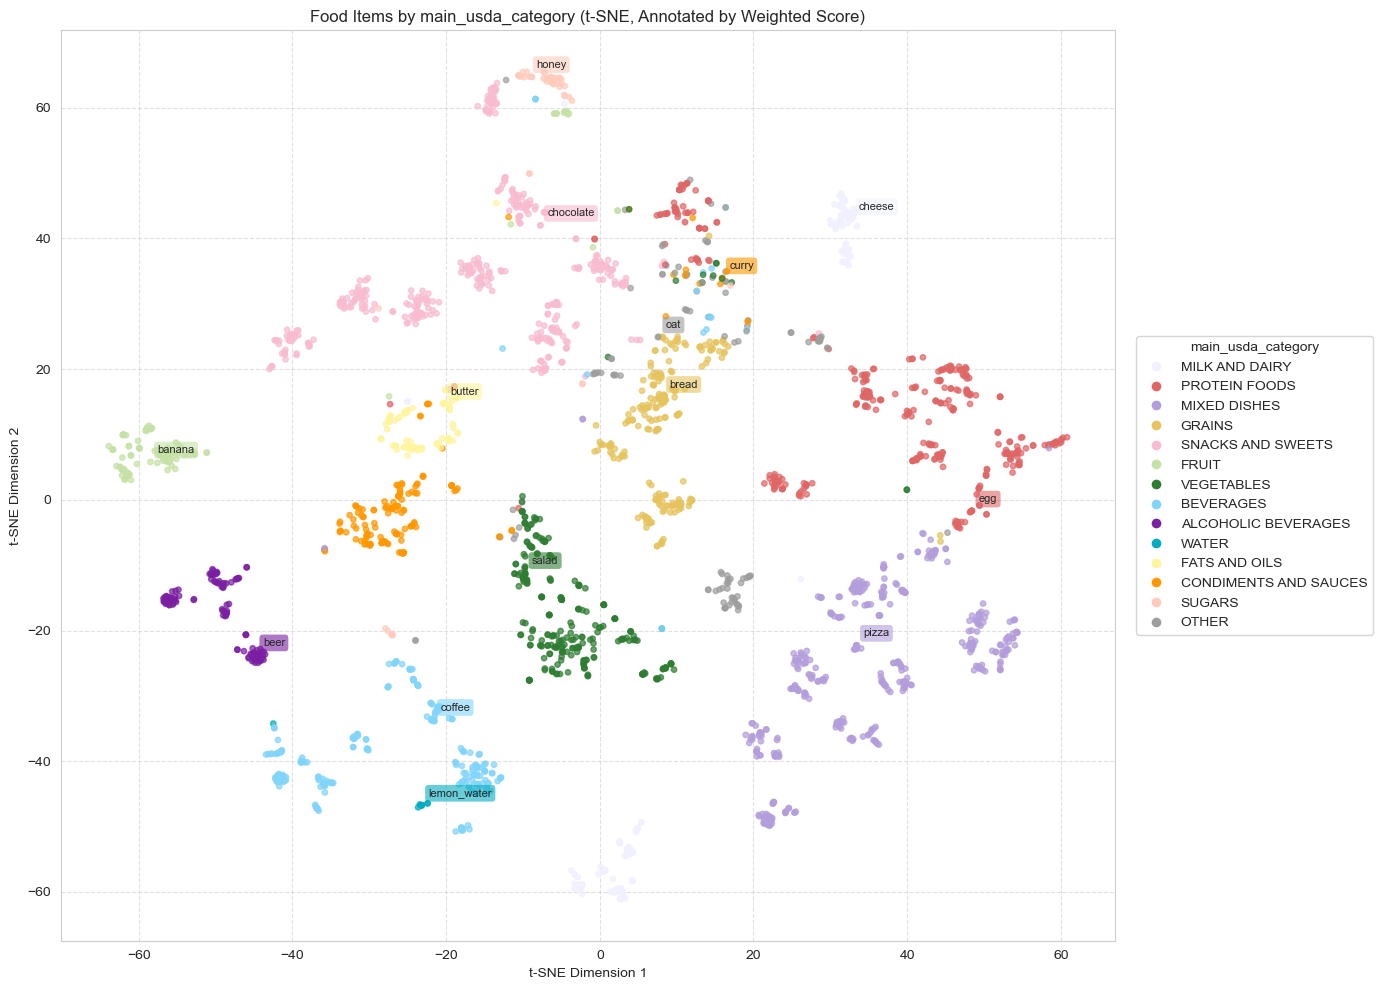

In [138]:
# Cell (e.g., Cell 10b): Enhanced Visualization with Annotations (Using External Frequencies)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.preprocessing import MinMaxScaler

# Assuming result_df, 'main_usda_category', and usda_colors are defined from previous cells
# Assuming result_df has a food name column matching the keys in overall_food_counts

def visualize_clusters_with_annotations(df, frequency_map, # <-- New argument: Pass overall_food_counts here
                                        tsne_1_col='tsne_1', tsne_2_col='tsne_2',
                                        food_name_col=None, # REQUIRED: Column in *df* matching keys in frequency_map
                                        category_col=None,
                                        custom_colors=None,
                                        annotate_categories=None,
                                        point_size=30,
                                        annotation_fontsize=9,
                                        annotation_offset=(5, 5),
                                        freq_weight=0.8,
                                        prox_weight=0.2):
    """
    Visualize clusters on t-SNE, color by category, and add annotations
    based on a weighted score of external frequency (from frequency_map)
    and centroid proximity within the plotted data (df).

    Args:
        df (pd.DataFrame): DataFrame with t-SNE, cluster, category, and food name columns.
        frequency_map (pd.Series or dict): Map of food names (keys) to their overall counts (values).
                                            Calculated externally (e.g., from food_df).
        tsne_1_col (str): Name of the t-SNE dimension 1 column in df.
        tsne_2_col (str): Name of the t-SNE dimension 2 column in df.
        food_name_col (str): Name of the column in df containing food item names
                             (must match keys in frequency_map). Required for annotations.
        category_col (str, optional): Name of categorical column in df for coloring.
        custom_colors (dict, optional): Dictionary mapping categories to colors.
        annotate_categories (list, optional): Specific list of category values in df to annotate.
        point_size (int): Size of the dots in the scatter plot.
        annotation_fontsize (int): Font size for annotations.
        annotation_offset (tuple): Text offset (x, y) in points from the annotated point.
        freq_weight (float): Weight applied to the normalized frequency score (0 to 1).
        prox_weight (float): Weight applied to the normalized proximity score (0 to 1).
    """
    # --- Input Validations ---
    if category_col and food_name_col is None:
        print("Warning: `food_name_col` not specified. Cannot add annotations.")
        annotate_flag = False
    elif category_col and frequency_map is None:
        print("Warning: `frequency_map` not provided. Cannot use external frequencies for annotations.")
        annotate_flag = False
    elif category_col and food_name_col and food_name_col not in df.columns:
        raise ValueError(f"Annotation column '{food_name_col}' not found in DataFrame 'df'.")
    else:
        annotate_flag = True # Can proceed with annotations

    if not all(c in df.columns for c in [tsne_1_col, tsne_2_col]):
        raise ValueError(f"t-SNE columns '{tsne_1_col}' or '{tsne_2_col}' not found in 'df'.")
    if category_col and category_col not in df.columns:
        raise ValueError(f"Category column '{category_col}' not found in 'df'.")
    if annotate_flag and not isinstance(frequency_map, (pd.Series, dict)):
        raise TypeError("`frequency_map` must be a pandas Series or a dictionary.")

    # Normalize weights (optional)
    total_weight = freq_weight + prox_weight
    if not np.isclose(total_weight, 1.0):
        print(f"Warning: Weights ({freq_weight}, {prox_weight}) do not sum to 1. Normalizing.")
        if total_weight > 0: freq_weight, prox_weight = freq_weight/total_weight, prox_weight/total_weight
        else: freq_weight, prox_weight = 0.5, 0.5

    # --- Plot Setup ---
    fig, scatter_ax = plt.subplots(figsize=(14, 10))
    annotations_to_add = []
    scaler = MinMaxScaler() # For scaling scores

    # --- Plotting Logic ---
    if category_col and category_col in df.columns:
        print(f"Visualizing clusters colored by {category_col}...")
        unique_categories_in_df = df[category_col].unique()

        categories_for_annotation = []
        if annotate_flag:
            # Determine which categories to annotate based on inputs
            potential_targets = []
            if annotate_categories:
                potential_targets = annotate_categories
            elif custom_colors:
                potential_targets = list(custom_colors.keys())
            else:
                potential_targets = list(unique_categories_in_df)
            # Filter targets to those actually present in the df
            categories_for_annotation = [cat for cat in potential_targets if cat in unique_categories_in_df]

            # --- Find Representative Points using Weighted Score ---
            print(f"Finding representative points for categories (weighted score using external freq): {categories_for_annotation}")

            for category in categories_for_annotation:
                subset = df[df[category_col] == category].copy()
                if subset.empty or len(subset) < 2:
                    print(f"Skipping category '{category}': not enough data points ({len(subset)}) in result_df")
                    continue

                # --- 1. Frequency Score (using external frequency_map) ---
                # Map the overall counts onto the current subset
                subset['overall_count'] = subset[food_name_col].map(frequency_map).fillna(0).astype(int)

                if subset['overall_count'].nunique() > 1:
                    subset['freq_score'] = scaler.fit_transform(subset[['overall_count']])
                elif subset['overall_count'].sum() > 0 : # All have same count > 0
                    subset['freq_score'] = 1.0 # Give max score if only one food type and it has counts
                else: # All counts are 0
                    subset['freq_score'] = 0.0 # Give min score if counts are all zero


                # --- 2. Proximity Score (calculated within subset's t-SNE space) ---
                centroid = subset[[tsne_1_col, tsne_2_col]].mean().values.reshape(1, -1)
                distances = euclidean_distances(subset[[tsne_1_col, tsne_2_col]].values, centroid).flatten()
                if np.ptp(distances) > 1e-6:
                    norm_distances = scaler.fit_transform(distances.reshape(-1, 1)).flatten()
                    subset['prox_score'] = 1.0 - norm_distances
                else:
                    subset['prox_score'] = 0.5 # Neutral score if all points equidistant


                # --- 3. Combined Score ---
                subset['combined_score'] = (freq_weight * subset['freq_score'] +
                                            prox_weight * subset['prox_score'])

                # --- 4. Select Best Point ---
                best_point_idx = subset['combined_score'].idxmax()
                representative_point = df.loc[best_point_idx]

                # Check if the chosen food actually had a count > 0
                chosen_count = subset.loc[best_point_idx, 'overall_count']
                # print(f"  Category: {category} - Chosen: {representative_point[food_name_col]} (Score: {subset.loc[best_point_idx, 'combined_score']:.3f}, FreqScore: {subset.loc[best_point_idx, 'freq_score']:.3f}, ProxScore: {subset.loc[best_point_idx, 'prox_score']:.3f}, Count: {chosen_count})")


                annotations_to_add.append({
                    'x': representative_point[tsne_1_col],
                    'y': representative_point[tsne_2_col],
                    'text': representative_point[food_name_col],
                    'category': category,
                    'score': subset.loc[best_point_idx, 'combined_score']
                })

        # --- Scatter Plotting (Identical to previous version) ---
        if custom_colors:
            colors = df[category_col].map(custom_colors).fillna('#9e9e9e')
            scatter_ax.scatter(df[tsne_1_col], df[tsne_2_col], c=colors, alpha=0.7, s=point_size, rasterized=True)
            valid_custom_colors = {k: v for k, v in custom_colors.items() if k in unique_categories_in_df}
            handles = [plt.Line2D([0], [0], marker='o', color='w', label=cat, markerfacecolor=color, markersize=8)
                       for cat, color in valid_custom_colors.items()]
            scatter_ax.legend(handles=handles, title=category_col, loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)
        else:
            palette = sns.color_palette("hsv", len(unique_categories_in_df))
            sns.scatterplot(data=df, x=tsne_1_col, y=tsne_2_col, hue=category_col, palette=palette,
                            alpha=0.7, s=point_size, ax=scatter_ax, legend='full', rasterized=True)
            scatter_ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0., title=category_col)

    else: # Fallback: Color by numerical cluster ID
        # (Identical to previous version)
        print("Visualizing clusters colored by 'cluster' column...")
        if 'cluster' not in df.columns: raise ValueError("DataFrame needs a 'cluster' column...")
        n_clusters = df['cluster'].nunique()
        palette = sns.color_palette("tab10", n_clusters) if n_clusters <= 10 else sns.color_palette("hsv", n_clusters)
        sns.scatterplot(data=df, x=tsne_1_col, y=tsne_2_col, hue='cluster', palette=palette,
                        alpha=0.7, s=point_size, ax=scatter_ax, legend='full', rasterized=True)
        scatter_ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0., title='Cluster ID')

    # --- Add Annotations (Identical to previous version) ---
    if annotations_to_add:
        print(f"Adding {len(annotations_to_add)} annotations...")
        for ann in annotations_to_add:
            ann_color = custom_colors.get(ann['category'], 'grey') if custom_colors else 'grey'
            scatter_ax.annotate(
                text=ann['text'][:30] + ('...' if len(ann['text']) > 30 else ''),
                xy=(ann['x'], ann['y']), xytext=annotation_offset, textcoords='offset points',
                ha='left', va='bottom', fontsize=annotation_fontsize,
                bbox=dict(boxstyle='round,pad=0.3', fc=ann_color, alpha=0.6, ec='none'),
            )

    scatter_ax.set_title(f"Food Items by {category_col or 'Cluster'} (t-SNE, Annotated by Weighted Score)" if category_col else "Food Clusters (t-SNE)")
    scatter_ax.set_xlabel("t-SNE Dimension 1")
    scatter_ax.set_ylabel("t-SNE Dimension 2")
    scatter_ax.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.subplots_adjust(right=0.8)
    plt.show()

# --- Step 3: Example Usage ---
# Cell (e.g., Cell 10c): Call Visualization with External Frequencies

# Ensure 'result_df' has 'tsne_1', 'tsne_2', 'main_usda_category',
# and a food name column (e.g., 'result_food_name') whose values
# match the food names used as index in 'overall_food_counts'.
# Ensure 'usda_colors' dictionary is defined.

# --- CONFIRM the food name column in result_df ---
result_df_food_col = 'food_name_safe' # <--- CHANGE if needed for result_df

if result_df_food_col not in result_df.columns:
    raise ValueError(f"Column '{result_df_food_col}' not found in result_df. This column should contain food names matching the frequency map.")

visualize_clusters_with_annotations(
    df=result_df, # The DataFrame with t-SNE coordinates
    frequency_map=overall_food_counts, # Pass the pre-calculated counts
    food_name_col=result_df_food_col, # Column in result_df to match freq map keys
    category_col='main_usda_category',
    custom_colors=usda_colors,
    annotate_categories=None, # Annotate categories from custom_colors
    point_size=15,
    annotation_fontsize=8,
    freq_weight=1.0,
    prox_weight=0.0
)

In [137]:
result_df = result_df.reset_index().rename(columns={'index': 'food_name_safe'})

Processing annotations within all main categories found.
Finding representative points for groups in 'main_usda_category'...
Identified 14 representative points for annotation.
Plotting points colored by main_usda_category...
Adding 14 annotations...


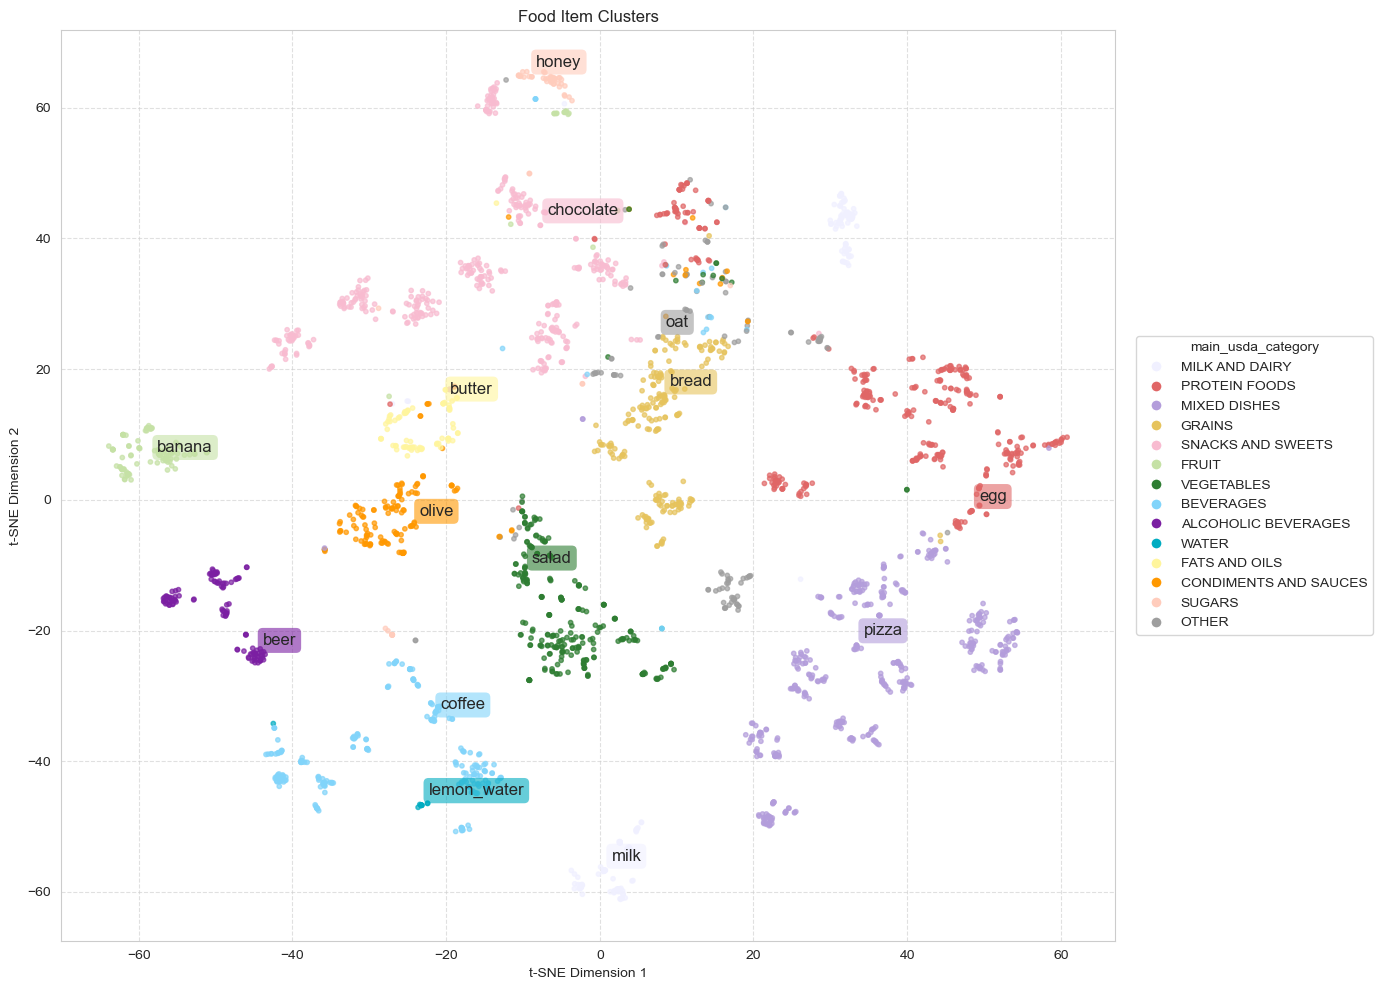

In [150]:
# Cell (e.g., Cell 10d): Visualization with Secondary Category Annotations
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.preprocessing import MinMaxScaler

# Assuming result_df, overall_food_counts, usda_colors are defined
# Assuming result_df has main_usda_category, usda_category (or similar secondary), and food_name_safe

def visualize_clusters_with_grouped_annotations(
        df, frequency_map,
        tsne_1_col='tsne_1', tsne_2_col='tsne_2',
        food_name_col=None,              # Col in df matching freq_map keys (e.g., 'food_name_safe')
        color_legend_col=None,         # Col for point colors & legend (e.g., 'main_usda_category')
        annotation_group_col=None,     # Col to group points for annotation (e.g., 'usda_category')
        custom_colors=None,            # Dict mapping color_legend_col values to colors
        main_categories_to_detail=None, # Optional list of main categories to show detailed annotations for
        point_size=30,
        annotation_fontsize=9,
        annotation_offset=(5, 5),
        freq_weight=0.8,
        prox_weight=0.2
):
    """
    Visualize t-SNE, color/legend by main category, annotate based on secondary category groups.

    Annotations select the best item within each secondary category group based on a
    weighted score of external frequency and proximity to the secondary group's centroid.

    Args:
        df (pd.DataFrame): DataFrame with t-SNE, food name, main & secondary category columns.
        frequency_map (pd.Series or dict): Map of food names to overall counts.
        tsne_1_col (str): t-SNE dimension 1 column name.
        tsne_2_col (str): t-SNE dimension 2 column name.
        food_name_col (str): Food name column in df (must match keys in frequency_map).
        color_legend_col (str): Column for coloring points and creating the legend.
        annotation_group_col (str): Column defining groups for annotation calculation.
        custom_colors (dict, optional): Map of color_legend_col values to colors.
        main_categories_to_detail (list, optional): If provided, only show annotations
            for secondary groups falling within these main categories. If None, attempts
            to annotate secondary groups within all main categories.
        point_size (int): Scatter plot point size.
        annotation_fontsize (int): Annotation text font size.
        annotation_offset (tuple): Annotation text offset (x, y) in points.
        freq_weight (float): Weight for frequency score (0-1).
        prox_weight (float): Weight for proximity score (0-1).
    """
    # --- Input Validations ---
    annotate_flag = True
    if not all(c in df.columns for c in [tsne_1_col, tsne_2_col]):
        raise ValueError(f"t-SNE columns '{tsne_1_col}' or '{tsne_2_col}' not found.")
    if color_legend_col and color_legend_col not in df.columns:
        raise ValueError(f"Color/Legend column '{color_legend_col}' not found.")
    if annotation_group_col and annotation_group_col not in df.columns:
        print(f"Warning: Annotation group column '{annotation_group_col}' not found. Cannot add annotations.")
        annotate_flag = False
    if annotate_flag and food_name_col is None:
        print("Warning: `food_name_col` not specified. Cannot add annotations.")
        annotate_flag = False
    if annotate_flag and food_name_col not in df.columns:
        raise ValueError(f"Annotation food name column '{food_name_col}' not found.")
    if annotate_flag and frequency_map is None:
        print("Warning: `frequency_map` not provided. Cannot use external frequencies.")
        annotate_flag = False
    if annotate_flag and not isinstance(frequency_map, (pd.Series, dict)):
        raise TypeError("`frequency_map` must be a pandas Series or a dictionary.")
    if color_legend_col is None and custom_colors:
        print("Warning: `custom_colors` provided but `color_legend_col` is None. Colors won't be used effectively.")

    # Normalize weights
    total_weight = freq_weight + prox_weight
    if not np.isclose(total_weight, 1.0):
        print(f"Warning: Weights ({freq_weight}, {prox_weight}) do not sum to 1. Normalizing.")
        if total_weight > 0: freq_weight, prox_weight = freq_weight / total_weight, prox_weight / total_weight
        else: freq_weight, prox_weight = 0.5, 0.5

    # --- Plot Setup ---
    fig, scatter_ax = plt.subplots(figsize=(14, 10))
    annotations_to_add = []
    scaler = MinMaxScaler()

    # --- Determine Main Categories to Process ---
    if color_legend_col:
        all_main_categories_in_df = df[color_legend_col].unique()
        if main_categories_to_detail:
            # Filter to only those requested main categories that actually exist in the data
            main_cats_to_process = [cat for cat in main_categories_to_detail if cat in all_main_categories_in_df]
            print(f"Processing annotations within main categories: {main_cats_to_process}")
        else:
            # Process all main categories found in the data
            main_cats_to_process = list(all_main_categories_in_df)
            print(f"Processing annotations within all main categories found.")
    else:
        # If no main category column, we can't filter by it. Will process all annotation groups.
        main_cats_to_process = [None] # Placeholder to run the annotation loop once

    # --- Find Representative Points (Grouped by Secondary Category) ---
    if annotate_flag:
        print(f"Finding representative points for groups in '{annotation_group_col}'...")
        processed_groups = 0
        # Iterate through the main categories we decided to process
        for main_cat_filter in main_cats_to_process:
            # Filter df by the current main category (if applicable)
            df_filtered_main = df if main_cat_filter is None else df[df[color_legend_col] == main_cat_filter]

            if df_filtered_main.empty:
                continue

            # Find unique secondary groups within this main category slice
            unique_secondary_groups = df_filtered_main[annotation_group_col].unique()

            # Iterate through each secondary group
            for secondary_group in unique_secondary_groups:
                # Create the subset based on the secondary group within the filtered main category slice
                subset = df_filtered_main[df_filtered_main[annotation_group_col] == secondary_group].copy()

                if subset.empty or len(subset) < 2:
                    # print(f"Skipping secondary group '{secondary_group}' within '{main_cat_filter or 'all'}': not enough data ({len(subset)})")
                    continue

                # --- Calculate Scores (within the secondary group subset) ---
                # 1. Frequency Score
                subset['overall_count'] = subset[food_name_col].map(frequency_map).fillna(0).astype(int)
                if subset['overall_count'].nunique() > 1: subset['freq_score'] = scaler.fit_transform(subset[['overall_count']])
                elif subset['overall_count'].sum() > 0: subset['freq_score'] = 1.0
                else: subset['freq_score'] = 0.0

                # 2. Proximity Score (to the secondary group's centroid)
                centroid = subset[[tsne_1_col, tsne_2_col]].mean().values.reshape(1, -1)
                distances = euclidean_distances(subset[[tsne_1_col, tsne_2_col]].values, centroid).flatten()
                if np.ptp(distances) > 1e-6:
                    subset['prox_score'] = 1.0 - scaler.fit_transform(distances.reshape(-1, 1)).flatten()
                else: subset['prox_score'] = 0.5

                # 3. Combined Score
                subset['combined_score'] = (freq_weight * subset['freq_score'] + prox_weight * subset['prox_score'])

                # 4. Select Best Point (within this secondary group)
                best_point_idx = subset['combined_score'].idxmax()
                representative_point = df.loc[best_point_idx] # Get the full row from original df

                # Store annotation info, including the main category for coloring the box
                main_category_for_box = representative_point[color_legend_col] if color_legend_col else None

                annotations_to_add.append({
                    'x': representative_point[tsne_1_col],
                    'y': representative_point[tsne_2_col],
                    'text': representative_point[food_name_col],
                    'main_category': main_category_for_box, # Store main category for annotation color
                    'secondary_group': secondary_group,
                    'score': subset.loc[best_point_idx, 'combined_score']
                })
                processed_groups += 1
        print(f"Identified {processed_groups} representative points for annotation.")


    # --- Scatter Plotting (Based on color_legend_col) ---
    if color_legend_col:
        print(f"Plotting points colored by {color_legend_col}...")
        if custom_colors:
            # Use custom colors provided, mapped to the color_legend_col
            colors = df[color_legend_col].map(custom_colors).fillna('#9e9e9e')
            scatter_ax.scatter(df[tsne_1_col], df[tsne_2_col], c=colors, alpha=0.7, s=point_size, rasterized=True)

            # Create legend using custom colors for categories present in the data
            valid_custom_colors = {k: v for k, v in custom_colors.items() if k in df[color_legend_col].unique()}
            handles = [plt.Line2D([0], [0], marker='o', color='w', label=cat, markerfacecolor=color, markersize=8)
                       for cat, color in valid_custom_colors.items()]
            scatter_ax.legend(handles=handles, title=color_legend_col, loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)
        else:
            # Use default palette if no custom colors
            palette = sns.color_palette("hsv", df[color_legend_col].nunique())
            sns.scatterplot(data=df, x=tsne_1_col, y=tsne_2_col, hue=color_legend_col, palette=palette,
                            alpha=0.7, s=point_size, ax=scatter_ax, legend='full', rasterized=True)
            scatter_ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0., title=color_legend_col)
    else:
        # Fallback: Plot all points in a single color if no color column specified
        print("Plotting all points in default color (no color_legend_col specified)...")
        scatter_ax.scatter(df[tsne_1_col], df[tsne_2_col], alpha=0.7, s=point_size, rasterized=True)


    # --- Add Annotations ---
    if annotations_to_add:
        print(f"Adding {len(annotations_to_add)} annotations...")
        for ann in annotations_to_add:
            # Get color for annotation box from the main category using custom_colors if available
            box_color = 'grey' # Default
            if custom_colors and ann['main_category'] is not None:
                box_color = custom_colors.get(ann['main_category'], 'grey')

            scatter_ax.annotate(
                text=ann['text'][:30] + ('...' if len(ann['text']) > 30 else ''),
                xy=(ann['x'], ann['y']), xytext=annotation_offset, textcoords='offset points',
                ha='left', va='bottom', fontsize=annotation_fontsize,
                bbox=dict(boxstyle='round,pad=0.3', fc=box_color, alpha=0.6, ec='none'),
            )

    plot_title = "Food Item Clusters"
    # if color_legend_col: plot_title += f" by {color_legend_col}"
    # if annotation_group_col: plot_title += f" (Annotated by {annotation_group_col} group)"
    scatter_ax.set_title(plot_title)
    scatter_ax.set_xlabel("t-SNE Dimension 1")
    scatter_ax.set_ylabel("t-SNE Dimension 2")
    scatter_ax.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.subplots_adjust(right=0.8)
    plt.show()


# --- Example Usage ---
# Cell (e.g., Cell 10e): Call Visualization with Secondary Group Annotations

# --- CONFIRM column names in result_df ---
result_df_food_col = 'food_name_safe' # Food name column matching frequency map keys
main_category_col = 'main_usda_category' # Column for coloring and legend
secondary_category_col = 'main_usda_category' # Column for grouping annotations

# Optional: Specify main categories you want to see detailed annotations for
# main_cats_to_show_details = ['VEGETABLES', 'FRUIT', 'PROTEIN FOODS']
main_cats_to_show_details = None # Set to None to annotate groups within ALL main categories

# Ensure required columns exist
required_cols = [result_df_food_col, main_category_col, secondary_category_col, 'tsne_1', 'tsne_2']
if not all(col in result_df.columns for col in required_cols):
    raise ValueError(f"result_df is missing one or more required columns: {required_cols}")

visualize_clusters_with_grouped_annotations(
    df=result_df,
    frequency_map=overall_food_counts,
    food_name_col=result_df_food_col,
    color_legend_col=main_category_col,         # Use main category for color/legend
    annotation_group_col=secondary_category_col, # Use secondary category for annotation grouping
    custom_colors=usda_colors,                 # Colors mapped to main category
    main_categories_to_detail=main_cats_to_show_details, # Filter which main cats get annotations
    point_size=10,
    annotation_fontsize=12, # Might need smaller font if many annotations
    freq_weight=0.8,       # Adjust weights as desired
    prox_weight=0.2
)

In [140]:
result_df

,food_name_safe,food_name,description,serving_size,macronutrients_per_100g,micronutrients_per_100g,usda_category,ingredients,variants,item_text,...,micro_magnesium_scaled,micro_vitamin_c_scaled,micro_phosphorus_scaled,micro_zinc_scaled,micro_riboflavin_scaled,micro_niacin_scaled,micro_potassium_scaled,cluster,tsne_1,tsne_2
0,chocolate_cookie,Chocolate Cookie,"A sweet baked treat, typically made with flour, sugar, butter, eggs, and chocolate or chocolate flavoring. Variations include different types of chocolate, nuts, and fillings.","{'grams': 30.0, 'household': '1 medium cookie'}","{'calories': 480.0, 'protein': 5.0, 'fat': 25.0, 'carbohydrates': 60.0, 'fiber': 2.0, 'sugar': 30.0, 'saturated_fat': 15.0, 'cholesterol': 50.0, 'sodium': 250.0}","{'calcium': 30.0, 'iron': 2.0, 'potassium': 150.0, 'vitamin_a': 50.0, 'vitamin_c': 0.0, 'vitamin_d': 0.0, 'vitamin_e': 0.5, 'vitamin_k': 2.0, 'thiamin': 0.1, 'riboflavin': 0.1, 'niacin': 0.5, 'vitamin_b6': 0.05, 'folate': 15.0, 'vitamin_b12': 0.0, 'phosphorus': 80.0, 'magnesium': 20.0, 'zinc': 0.5, 'selenium': 5.0}","{'main_category': 'SNACKS AND SWEETS', 'secondary_category': 'Sweet Bakery Products', 'third_category': 'Cookies and brownies'}","[Flour, Sugar, Butter, Eggs, Chocolate chips or cocoa powder, Vanilla extract, Baking soda, Salt]","[Chocolate chip cookie, Double chocolate cookie, Chocolate fudge cookie, Peanut butter chocolate cookie, Vegan chocolate cookie, Gluten-free chocolate cookie]","Chocolate Cookie A sweet baked treat, typically made with flour, sugar, butter, eggs, and chocolate or chocolate flavoring. Variations include different types of chocolate, nuts, and fillings. {'main_category': 'SNACKS AND SWEETS', 'secondary_category': 'Sweet Bakery Products', 'third_category': 'Cookies and brownies'}",...,-0.177945,-0.093555,-0.268127,-0.233618,-0.062182,-0.132270,-0.304819,0,-17.086496,35.827583
1,green_apple_amino_energy,Amino Energy Green Apple,"A green apple flavored, lightly carbonated beverage marketed as a pre-workout or energy drink, containing amino acids, caffeine, and electrolytes.","{'grams': 9.0, 'household': '1 scoop (approximate)'}","{'calories': 0.0, 'protein': 0.0, 'fat': 0.0, 'carbohydrates': 0.0, 'fiber': 0.0, 'sugar': 0.0, 'saturated_fat': None, 'cholesterol': None, 'sodium': 0.0}","{'calcium': None, 'iron': None, 'potassium': None, 'vitamin_a': None, 'vitamin_c': None, 'vitamin_d': None, 'vitamin_e': None, 'vitamin_k': None, 'thiamin': None, 'riboflavin': None, 'niacin': None, 'vitamin_b6': None, 'folate': None, 'vitamin_b12': None, 'phosphorus': None, 'magnesium': None, 'zinc': None, 'selenium': None}","{'main_category': 'BEVERAGES', 'secondary_category': 'Sweetened Beverages', 'third_category': 'Sport and energy drinks'}","[Amino Blend (L-Glutamine, L-Leucine, L-Arginine, L-Isoleucine, L-Valine, L-Tyrosine, L-Lysine Hydrochloride, L-Phenylalanine, L-Threonine), Caffeine (from Green Tea and/or Green Coffee Bean), Citric Acid, Malic Acid, Natural and Artificial Flavors, Silicon Dioxide, Calcium Silicate, Sucralose, Gum Blend (Cellulose Gum, Xanthan Gum, Carrageenan), Inulin, Green Apple Color]","[Various flavors (e.g., Fruit Fusion, Watermelon, Blue Raspberry), Different package sizes (e.g., tubs, single-serving packets), Caffeinated and non-caffeinated versions]","Amino Energy Green Apple A green apple flavored, lightly carbonated beverage marketed as a pre-workout or energy drink, containing amino acids, caffeine, and electrolytes. {'main_category': 'BEVERAGES', 'secondary_category': 'Sweetened Beverages', 'third_category': 'Sport and energy drinks'}",...,-0.454100,-0.093555,-0.803500,-0.434661,-0.134712,-0.172133,-0.826172,-1,-26.708151,-25.017832
2,bud_light_beer,Bud Light Beer,"A light-bodied American lager known for its crisp, clean flavor and low calorie content.","{'grams': 355.0, 'household': '1 can (12 fl oz)'}","{'calories': 28.0, 'protein': 0.2, 'fat': 0.0, 'carbohydrates': 1.7, 'fiber': 0.0, 'sugar': 0.0, 'saturated_fat': 0.0, 'cholesterol

In [111]:
result_df[result_df['main_usda_category'] == 'ALCOHOLIC BEVERAGES']['food_name'].value_counts()

food_name
Sauvignon Blanc Wine       2
White Claw Hard Seltzer    2
Pinot Noir Wine            2
Wine, Table, All           2
Moscow Mule                2
                          ..
Sake                       1
Bailey's Irish Cream       1
Pina Colada                1
Chardonnay Wine            1
Moscato Wine               1
Name: count, Length: 107, dtype: int64

Visualizing clusters colored by main_usda_category...


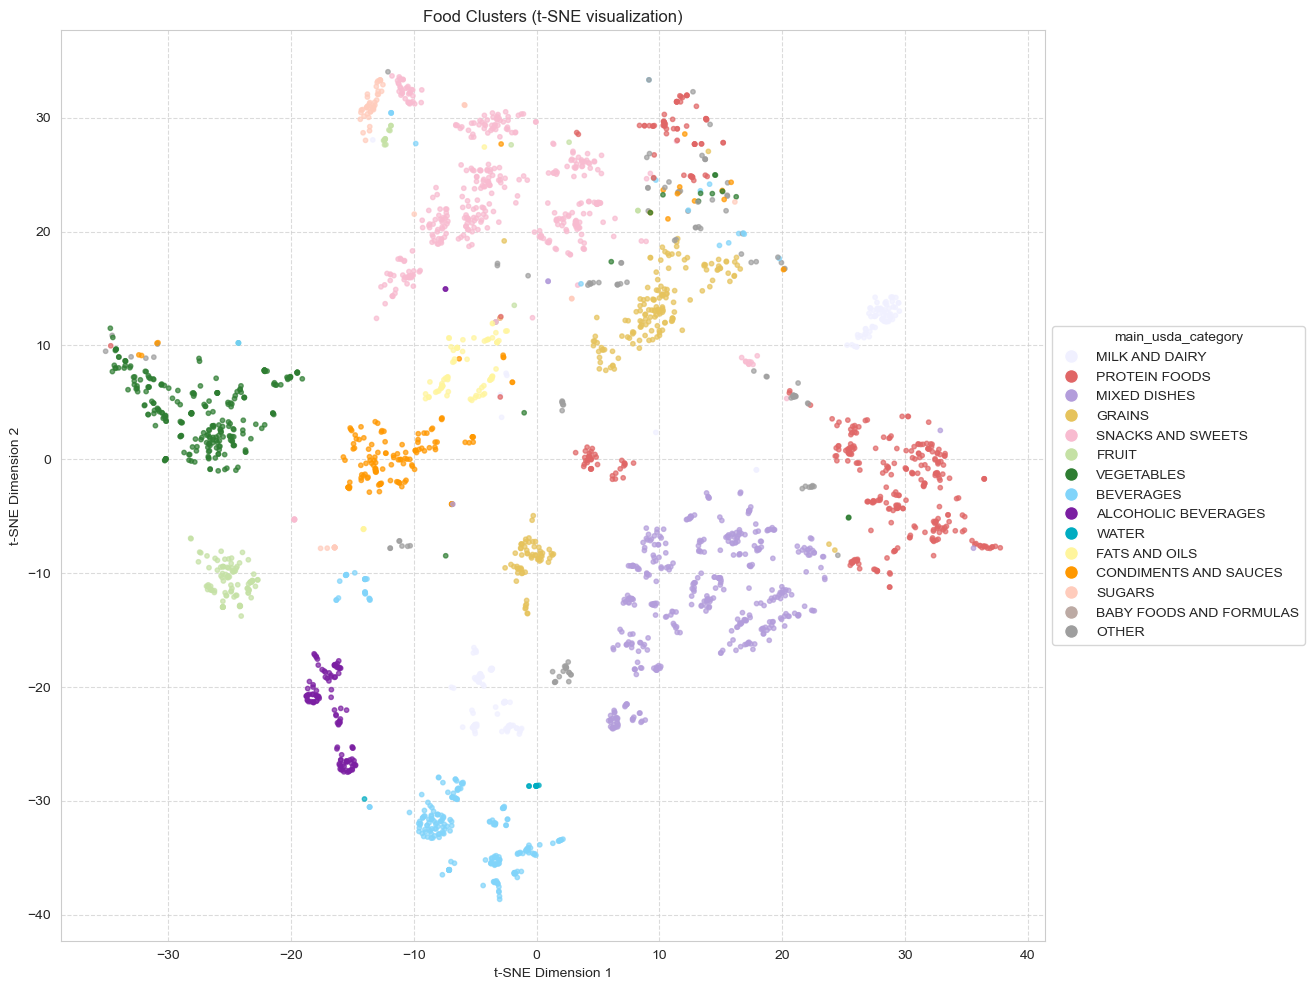

In [61]:
# 100
visualize_clusters(result_df, category_col='main_usda_category', custom_colors=usda_colors, point_size=10)

Visualizing clusters colored by main_usda_category...


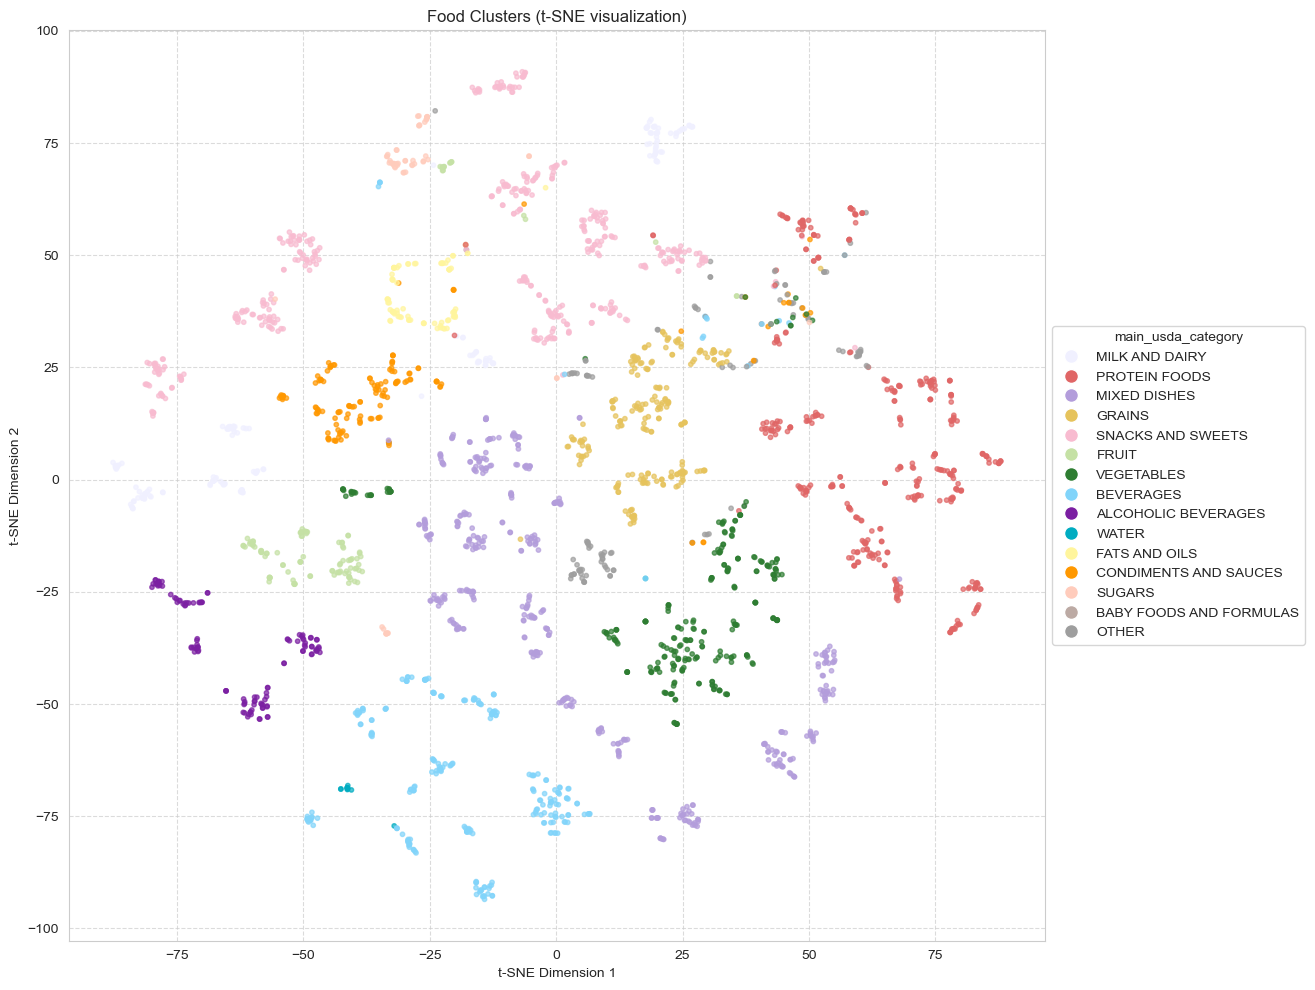

In [64]:
# 10
visualize_clusters(result_df, category_col='main_usda_category', custom_colors=usda_colors, point_size=10)

Visualizing clusters colored by kmeans_9_cluster...


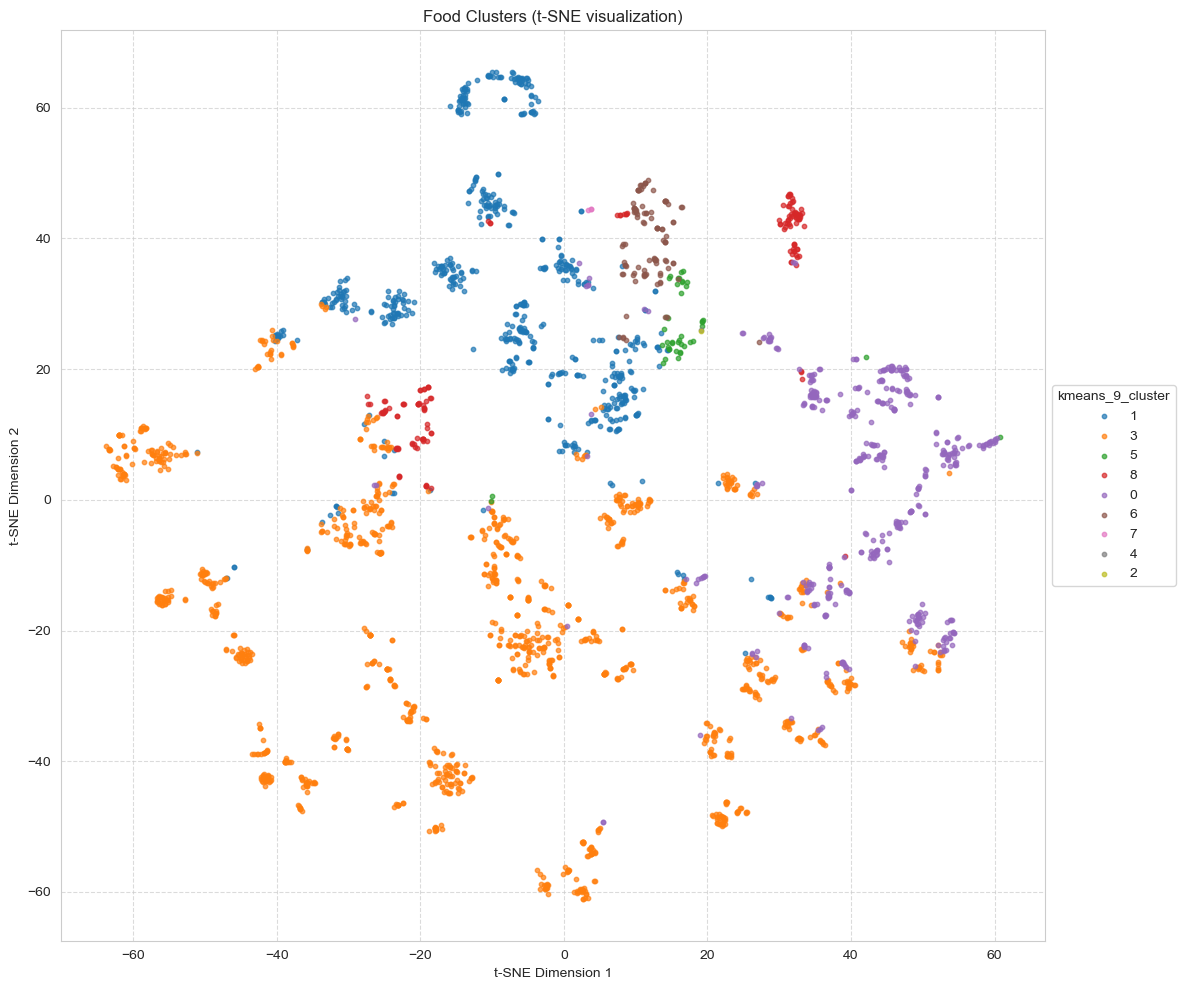

In [55]:
visualize_clusters(result_df, category_col='kmeans_9_cluster',  point_size=10)

In [ ]:
visualize_clusters(result_df, category_col='main_usda_category', custom_colors=usda_colors)

In [ ]:

# Step 10: Analyze cluster characteristics
def analyze_cluster_nutrition(df, cluster_col='cluster', nutrition_cols=None):
    """
    Analyze nutritional characteristics of each cluster

    Args:
        df (pd.DataFrame): DataFrame with cluster assignments
        cluster_col (str): Name of cluster column
        nutrition_cols (list): List of nutritional columns to analyze

    Returns:
        pd.DataFrame: Cluster nutrition statistics
    """
    if not nutrition_cols:
        print("No nutrition columns specified for analysis")
        return None

    print(f"Analyzing nutritional profiles of {df[cluster_col].nunique()} clusters...")

    # Calculate mean values for each nutritional feature by cluster
    cluster_means = df.groupby(cluster_col)[nutrition_cols].mean()

    # Plot heatmap of cluster nutritional profiles
    plt.figure(figsize=(14, len(nutrition_cols) * 0.3 + 3))

    # Standardize values for better visualization
    cluster_means_std = (cluster_means - cluster_means.mean()) / cluster_means.std()

    # Create heatmap
    sns.heatmap(cluster_means_std.T, cmap='RdBu_r', center=0, annot=False,
                fmt='.2f', linewidths=0.5, cbar_kws={'label': 'Standard deviation from mean'})
    plt.title('Nutritional Profile by Cluster (Standardized)')
    plt.tight_layout()
    plt.show()

    # Return raw cluster means for detailed analysis
    return cluster_means

# Cell 10: Visualize clusters with USDA category coloring



In [ ]:

# Step 11: Analyze categorical distribution in clusters
def analyze_cluster_categories(df, cluster_col='cluster', category_col=None):
    """
    Analyze categorical distribution within each cluster

    Args:
        df (pd.DataFrame): DataFrame with cluster assignments
        cluster_col (str): Name of cluster column
        category_col (str): Categorical column to analyze

    Returns:
        pd.DataFrame: Category distribution within clusters
    """
    if not category_col or category_col not in df.columns:
        print("No category column specified for analysis")
        return None

    print(f"Analyzing {category_col} distribution across {df[cluster_col].nunique()} clusters...")

    # Calculate category frequencies within each cluster
    cluster_categories = pd.crosstab(
        df[cluster_col],
        df[category_col],
        normalize='index'
    ) * 100

    # Plot heatmap of category distribution
    plt.figure(figsize=(12, 8))
    sns.heatmap(cluster_categories, cmap='viridis', annot=True,
                fmt='.1f', linewidths=0.5, cbar_kws={'label': 'Percentage (%)'})
    plt.title(f'{category_col} Distribution by Cluster')
    plt.tight_layout()
    plt.show()

    # Print dominant category in each cluster
    print("Dominant categories in each cluster:")
    for cluster in cluster_categories.index:
        dominant = cluster_categories.loc[cluster].idxmax()
        percentage = cluster_categories.loc[cluster, dominant]
        print(f"Cluster {cluster}: {dominant} ({percentage:.1f}%)")

    return cluster_categories


# Cell 11: Analyze nutritional profiles of clusters
nutrition_analysis = analyze_cluster_nutrition(result_df, nutrition_cols=nutrition_cols)


In [ ]:

# Cell 12: Analyze category distribution in clusters
category_analysis = analyze_cluster_categories(result_df, category_col='main_usda_category')